In [3]:
1+1

2

In [13]:
import numpy as np
import pandas as pd
import math
import uproot

from pyanalib.dataset import Dataset
from pyanalib.panda_helpers import *
import weights

import reweight_coh
import numiweight

import matplotlib.pyplot as plt
import pickle
import h5py
import math

from unc_funcs import *
from unc_samples import *
#from unc_MCdata_overhead import *
from unc_cuts import *
from data import *

#import warnings
#warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

#import subprocess

## August 21, 2025:
dataframe I made from stuff I staged from tape:

In [3]:
f = "/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/nomNus.df"
evtdf = pd.read_hdf(f,key='evt')

In [4]:
print(evtdf.shape)

(2379, 293)


## Read additional things into the dataframes from the CAF files

In [4]:
with h5py.File("/exp/icarus/data/users/jdyer/dimuon-data/2501_moreCohlike/more_Cohlike.df", 'r') as f:
    keys_list = list(f.keys())
    print(keys_list)

['evt', 'hdr', 'mch', 'mcnu', 'mcnuwgt']


In [5]:
f = "/exp/icarus/data/users/jdyer/dimuon-data/2501_moreCohlike/more_Cohlike.df"
evtdf = pd.read_hdf(f,key='evt')


In [9]:
for c in evtdf.columns: 
    #if 'mcs' in c: print(c)
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('slc', 'truth', 'iscc', '', '', '')
('slc', 'truth', 'genie_mode', '', '', '')
('slc', 'truth', 'parent_pdg', ''

In [8]:
print(min(evtdf.trunk.trk.mcsP.fwdP_muon[evtdf.trunk.trk.mcsP.fwdP_muon != -1]))
print(min(evtdf.branch.trk.mcsP.fwdP_muon[evtdf.branch.trk.mcsP.fwdP_muon != -1]))


evtdf_ = pd.read_hdf(f,key='evt')

0.009999999776482582
0.009999999776482582


In [4]:
from pyanalib.panda_helpers import *

caf_f = uproot.open("/pnfs/icarus/scratch/users/gputnam/DMCP2023G/jamie-gen/MCNuTemplateD/73445101_513/prodcorsika_standard_icarus_20250122T001713-AddCorsika_20250122T005735-G4_20250122T024353-DetSim_20250122T032406-MCstage0_20250122T034822-MCstage1.flat.caf.root")

pfpbranch = "rec.slc.reco.pfp."
trkbranch = pfpbranch + "trk."
trkmcsbranches = [
  trkbranch + "mcsP.seg_length",
  trkbranch + "mcsP.seg_scatter_angles",
]

mcsdf = loadbranches(caf_f["recTree"], [trkmcsbranches[0]]).rec.slc.reco.pfp.trk.mcsP # seg_length
mcsdf_angle = loadbranches(caf_f["recTree"], [trkmcsbranches[1]]).rec.slc.reco.pfp.trk.mcsP

In [ ]:
nseg = mcsdf.groupby(level=[0,1,2]).count() # number of MCS segments.
#nseg

In [5]:
mcsP_df = loadbranches(caf_f["recTree"], [trkbranch + "mcsP.fwdP_muon"]).rec.slc.reco.pfp.trk.mcsP
mcsP_df

fwdP_muon
entry rec.slc..index rec.slc.reco.pfp..index           
0     0              0                              NaN
                     1                             0.09
                     2                             0.56
      1              0                              NaN
                     1                             0.49
...                                                 ...
42    37             0                              NaN
                     1                             0.25
      38             0                              NaN
                     1                              NaN
                     2                             0.01

[13617 rows x 1 columns]

In [19]:
#print(mcsdf.shape)
print(mcsP_df.shape)
print(mcsP_df[~mcsP_df.fwdP_muon.isna()].shape)
print(nseg.shape)

fin_mcsP = np.array(mcsP_df[~mcsP_df.fwdP_muon.isna()]) # finite values only; shape matches nseg shape.
nseg = np.array(nseg)

(13617, 1)
(2329, 1)
(2329, 1)


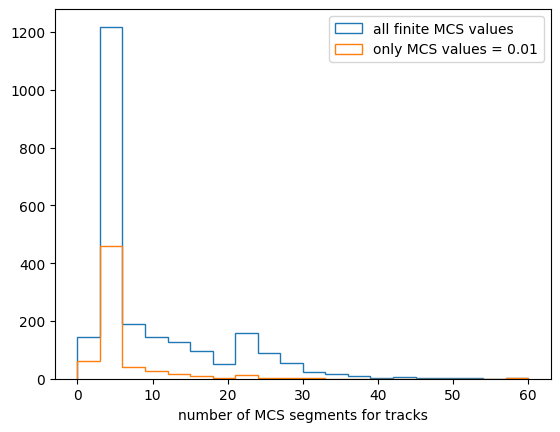

In [22]:
#print(nseg[fin_mcsP==0.01])
mybins=20
myRange=(0,60)
plt.hist(nseg, label='all finite MCS values', histtype='step', bins=mybins, range=myRange)
plt.hist(nseg[fin_mcsP==0.01], label='only MCS values = 0.01', histtype='step', bins=mybins, range=myRange)
plt.legend()
plt.xlabel('number of MCS segments for tracks')
plt.show()

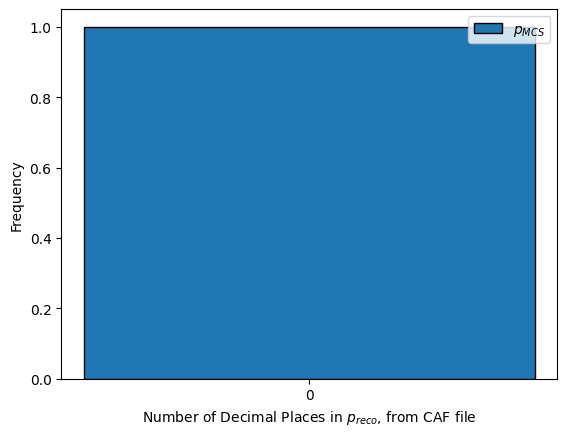

In [7]:

def get_decimal_places(number):
    s = str(number)
    if '.' in s:
        return len(s) - s.index('.') - 1
    return 0

# Get the number of decimal places for each element
mcs_decimal_place_counts = [get_decimal_places(f) for f in mcsdf]

# Determine appropriate bins for the histogram
max_decimals = max(mcs_decimal_place_counts)
bins = np.arange(max_decimals + 2) - 0.5 # Center bins around integer counts

# Create the histogram
plt.hist(mcs_decimal_place_counts, bins=bins, edgecolor='black', rwidth=0.8, label='$p_{MCS}$')
plt.legend()
plt.xlabel("Number of Decimal Places in $p_{reco}$, from CAF file")
plt.ylabel("Frequency")
plt.xticks(range(max_decimals + 1)) # Ensure integer ticks on x-axis
plt.show()

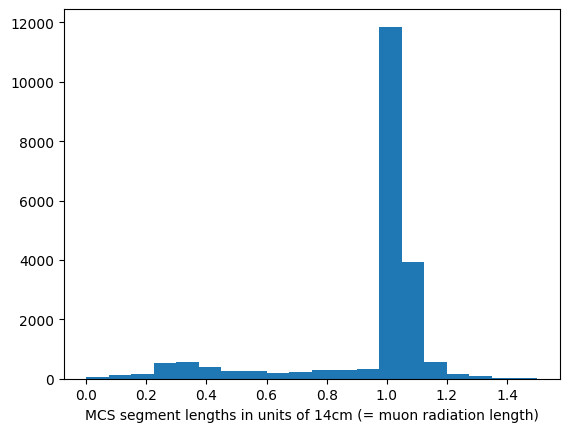

-999.0
30.03345489501953


In [16]:
plt.hist(mcsdf.seg_length, range=(0,1.5), bins=20)
plt.xlabel('MCS segment lengths in units of 14cm (= muon radiation length)')
plt.show()
print(min(mcsdf.seg_length))
print(max(mcsdf.seg_length))

In [21]:
mcsdf = loadbranches(caf_f["recTree"], [trkmcsbranches[0]]).rec.slc.reco.pfp.trk.mcsP
print(mcsdf.shape)
mcsdf_angle = loadbranches(caf_f["recTree"], [trkmcsbranches[1]]).rec.slc.reco.pfp.trk.mcsP
print(mcsdf.shape)
mcsdf_angle.index.set_names(mcsdf.index.names, inplace=True)

mcsdf = mcsdf.merge(mcsdf_angle, how="left", left_index=True, right_index=True)
print(mcsdf.shape)
mcsgroup = list(range(mcsdf.index.nlevels-1))
cumlen = mcsdf.seg_length.groupby(level=mcsgroup).cumsum()*14 # convert rad length to cm
maxlen = (cumlen*(mcsdf.seg_scatter_angles >= 0)).groupby(level=mcsgroup).max()
#trkdf[("pfp", "trk", "mcsP", "len", "", "")] = maxlen

# Note: the seg length is in units of 14 cm (which is radiation length). Not exactly 14 because has to go off of actual hits.


(20614, 1)
(20614, 1)
(20614, 2)


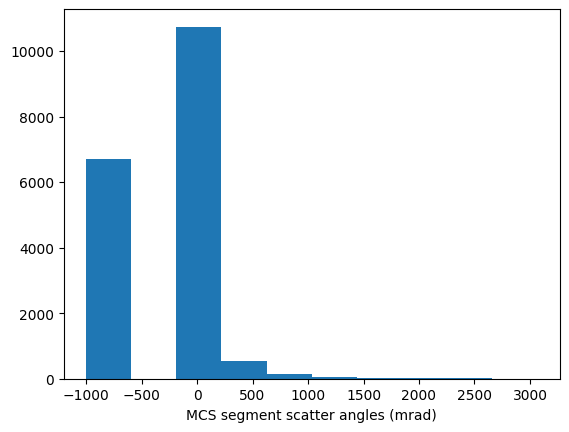

-57.23848342895508
175.53591918945312


In [64]:
plt.hist(mcsdf.seg_scatter_angles)#*180./(1000.*math.pi), bins=18, range=(-0,180)) # default units are in mrad.
plt.xlabel('MCS segment scatter angles (mrad)')
plt.show()
print(min(mcsdf.seg_scatter_angles*180./(1000.*math.pi)))
print(max(mcsdf.seg_scatter_angles*180./(1000.*math.pi)))

In [ ]:
print(.shape)

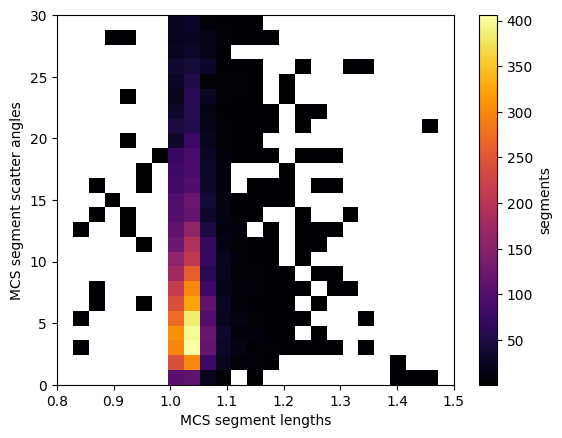

In [36]:
#WIP

fig, ax = plt.subplots(ncols=1)
#fig, ax = plt.subplot(1,2,1)
hb, xedges, yedges, im = ax.hist2d(mcsdf.seg_length, 
                                   mcsdf.seg_scatter_angles, 
                                   bins=[25, 25],
                                   cmin=1, cmap='inferno',
                                   range=((0.8,1.5),(0,30))
                                   #range=((-999,30),(-999,4000))
                                  )
fig.colorbar(im, ax=ax, label="segments")#, "log10(Entries)")
plt.xlabel('MCS segment lengths')
plt.ylabel('MCS segment scatter angles')
#plt.title(title+'\nMCS Mom. Reconstruction \nfor Selected Contained Tracks')
plt.show()

In [66]:
physical_angles = ((mcsdf_angle.seg_scatter_angles*180./(1000.*math.pi) >= 0) & (mcsdf_angle.seg_scatter_angles*180./(1000.*math.pi) <= 180.))
mean_angle = mcsdf_angle[physical_angles].seg_scatter_angles.groupby(level=mcsgroup).mean()*180./(1000.*math.pi)
mean_angle
max_angle = mcsdf_angle[physical_angles].seg_scatter_angles.groupby(level=mcsgroup).max()*180./(1000.*math.pi)
std_angle = mcsdf_angle[physical_angles].seg_scatter_angles.groupby(level=mcsgroup).std()*180./(1000.*math.pi)
print(mcsdf_angle.shape)
print(mcsdf_angle[physical_angles].shape)
print(mcsdf_angle[physical_angles].shape[0]/mcsdf_angle.shape[0])

(18285, 1)
(11567, 1)
0.6325950232430955


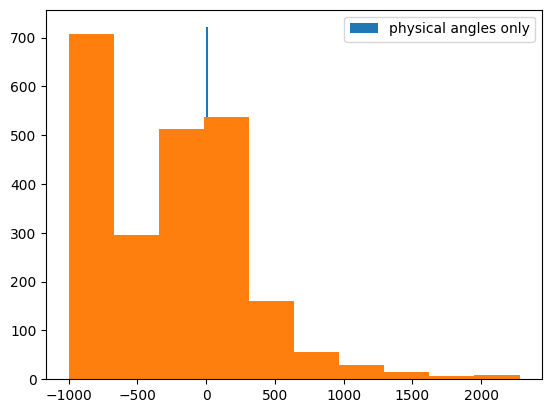

In [44]:
plt.hist(mean_angle, label='physical angles only', histtype='line')
plt.hist(mcsdf_angle.seg_scatter_angles.groupby(level=mcsgroup).mean(), histtype='line')
plt.legend()
plt.show()

In [14]:
mcsdf = loadbranches(caf_f["recTree"], [trkmcsbranches[0]]).rec.slc.reco.pfp.trk.mcsP


In [19]:
mcsdf


seg_length
entry rec.slc..index rec.slc.reco.pfp..index rec.slc.reco.pfp.trk.mcsP.seg_length..index            
0     0              1                       0                                              0.433331
                                             1                                              0.435620
                                             2                                              0.430189
                     2                       0                                              1.019555
                                             1                                              1.032758
...                                                                                              ...
42    37             1                       1                                              1.067794
                                             2                                              1.006110
      38             2                       0                                              0.553712
                                             1                                              0.548049
                                             2                                              0.535608

[20614 rows x 1 columns]

In [16]:
mcsgroup = list(range(mcsdf.index.nlevels-1))


In [17]:
mcsgroup


[0, 1, 2]

In [18]:
mcsdf.seg_length.groupby(level=mcsgroup)


In [20]:
print(mcsdf.shape)


(20614, 1)


In [6]:
print(mcsdf_angle.shape)
mcsdf_angle



(18285, 1)


seg_scatter_angles
entry rec.slc..index rec.slc.reco.pfp..index rec.slc.reco.pfp.trk.mcsP.seg_scatter_angles..i...                    
0     0              1                       0                                                           421.605774
                                             1                                                           629.432556
                     2                       0                                                            62.064316
                                             1                                                            43.924957
                                             2                                                           106.730766
...                                                                                                             ...
42    36             4                       2                                                          -999.000000
      37             1                       0                                                            44.808064
                                             1                                                           135.288559
      38             2                       0                                                          -999.000000
                                             1                                                          -999.000000

[18285 rows x 1 columns]

In [3]:
caf_f = uproot.open("/pnfs/icarus/scratch/users/gputnam/DMCP2023G/jamie-gen/MCNuTemplateD/73445101_999/prodcorsika_standard_icarus_20250122T004832-AddCorsika_20250122T020643-G4_20250122T053515-DetSim_20250122T065127-MCstage0_20250122T073523-MCstage1.flat.caf.root")

In [6]:
pfpbranch = "rec.slc.reco.pfp."
trkbranch = pfpbranch + "trk."
trkmcsbranches = [
  trkbranch + "mcsP.seg_length",
  trkbranch + "mcsP.seg_scatter_angles",
]
pfp_daughter_branch = [
    pfpbranch + "daughters"
]
dbranch = loadbranches(caf_f["recTree"], pfp_daughter_branch).rec.slc.reco.pfp.daughters

In [7]:
dbranch

entry  rec.slc..index  rec.slc.reco.pfp..index  rec.slc.reco.pfp.daughters..index
0      0               0                        0                                     5
                                                1                                    25
                                                2                                    38
       1               0                        0                                    14
                                                1                                    16
                                                                                     ..
47     29              15                       11                                   79
                                                12                                   81
                                                13                                   92
                                                14                                   93
       30              1              

In [4]:
d_df = loadbranches(caf_f["recTree"], ["rec.slc.reco.pfp.daughters"]).rec.slc.reco.pfp
d_df



daughters
entry rec.slc..index rec.slc.reco.pfp..index rec.slc.reco.pfp.daughters..index           
0     0              0                       0                                          5
                                             1                                         25
                                             2                                         38
      1              0                       0                                         14
                                             1                                         16
...                                                                                   ...
47    29             15                      11                                        79
                                             12                                        81
                                             13                                        92
                                             14                                        93
      30             1                       0                                         38

[14224 rows x 1 columns]

In [ ]:
# Troubleshooting dataframe maker on September 8, 2025

In [3]:
f = uproot.open("/pnfs/icarus/archive/sam_managed_users/gputnam/data/a/c/4/7/ff1ab0ce-a37f-4fd8-92e6-6d2eefdcb96f-prodcorsika_standard_icarus_20240205T054117-AddCorsika_20240205T070209-G4_20240205T115008-DetSim_20240205T140254-MCstage0_20240205T144653-MCstage1.flat.caf.root")

pfpbranch = "rec.slc.reco.pfp."
trkbranch = pfpbranch + "trk."
#shwbranch = pfpbranch + "shw."
pfpbranches = [
    pfpbranch + "parent_is_primary",
    pfpbranch + "slcID",
    pfpbranch + "trackScore",
    pfpbranch + "parent",
    pfpbranch + "id",
    pfpbranch + "t0",
    pfpbranch + "ndaughters" # added by JD 250701 # added by JD 100325
]
trkbranches = [
    trkbranch + "producer",
    trkbranch + "start.x", trkbranch + "start.y", trkbranch + "start.z",
    trkbranch + "end.x", trkbranch + "end.y", trkbranch + "end.z",
    trkbranch + "dir.x", trkbranch + "dir.y", trkbranch + "dir.z",
    trkbranch + "dir_end.x", trkbranch + "dir_end.y", trkbranch + "dir_end.z", # added by JD 10_03_25 (day/month/year)
    trkbranch + "len",
    trkbranch + "rangeP.p_muon",
    trkbranch + "mcsP.fwdP_muon",
    trkbranch + "rangeP.p_pion",
    trkbranch + "mcsP.fwdP_pion",
    trkbranch + "bestplane",
    trkbranch + "crthit.distance",
    trkbranch + "crthit.hit.time",
    trkbranch + "crthit.hit.pe",
    trkbranch + "chi2pid.2.pid_ndof",
    trkbranch + "chi2pid.2.chi2_muon",
    trkbranch + "chi2pid.2.chi2_proton",
    trkbranch + "chi2pid.2.chi2_pion",
    trkbranch + "chi2pid.2.chi2_kaon",
    trkbranch + "chi2pid.2.pida",
    trkbranch + "truth.p.crosses_tpc",
    trkbranch + "truth.p.startT",
    # trkbranch + "truth.p.start_process"
    # trkbranch + "truth.p.end_process",
] + pfpbranches

trkdf = loadbranches(f["recTree"], trkbranches)# + shwbranches)
trkdf = trkdf.rec.slc.reco


In [11]:
pfp_daughter_branch = [
    pfpbranch + "daughters"
]
ddf  = loadbranches(f["recTree"], pfp_daughter_branch).rec.slc.reco.pfp
trkmerge = trkdf[[("pfp", "id", "", "", "", ""),("pfp", "trk", "len", "", "", ""),("pfp", "trackScore", "", "", "", ""),("pfp", "trk", "start", "x", "", ""),("pfp", "trk", "start", "y", "", ""),("pfp", "trk", "start", "z", "", "")]]
trkmerge.columns = ["id", "len","trackScore","start_x","start_y","start_z"]
ddf_index = ddf.index.names
ddf = ddf.reset_index().merge(trkmerge.reset_index(), how="left", suffixes=("", "_t"), left_on=["entry", "rec.slc..index", "daughters"],right_on=["entry", "rec.slc..index", "id"]).set_index(ddf_index)
ddf = ddf[~pd.isna(ddf.len)]

In [12]:
longest_idx = ddf.len.groupby(level=[0,1,2]).idxmax()

In [14]:
longest_ddf = ddf.loc[longest_idx].droplevel(-1)

In [33]:
pfpid_daughters_df = pfpid_df["id"][pfpid_df["id"]==d_df["daughters"].groupby([0,1,2])]
pd.DataFrame(pfpid_daughters_df)

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/pandas/core/computation/expressions.py:70: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return op(a, b)


,,,id
entry,rec.slc..index,rec.slc.reco.pfp..index,


In [21]:
pfp_levels = d_df.index.nlevels 
pfp_levels-1

3

In [ ]:
longest_daughters = is_proton(df.pfp.trk).groupby(level=list(range(2))).sum()

In [25]:
#longest_daughter = trk_slcdf.pfp.dist_to_vertex.loc[not_trunk_branch].groupby(level=trklevel).idxmin().dropna()
pfpid_df = loadbranches(caf_f["recTree"], ["rec.slc.reco.pfp.id"]).rec.slc.reco.pfp
pfpid_df

id
entry rec.slc..index rec.slc.reco.pfp..index     
0     0              0                        193
                     1                         38
                     2                         25
                     3                          5
      1              0                        194
...                                           ...
47    29             13                        40
                     14                        33
                     15                         4
      30             0                         38
                     1                         13

[15760 rows x 1 columns]

In [10]:
n_proton = is_proton(df.pfp.trk).groupby(level=list(range(df.index.nlevels-1))).sum()


trk_slcdf = make_slc_trkdf(caf_f, trkDistCut=-1)
slcdf = trk_slcdf.copy()

trklevel = list(range(slcdf.index.nlevels-1))
trunk = slcdf.pfp.dist_to_vertex[is_muon(slcdf.pfp)].groupby(level=trklevel).idxmin()
trunkdf = slcdf.loc[trunk].droplevel(slcdf.index.nlevels-1)

nottrunk = slcdf.index.difference(trunk)
branch = slcdf.pfp.dist_to_vertex.loc[nottrunk][is_muon(slcdf.pfp.loc[nottrunk])].groupby(level=trklevel).idxmin()
branchdf = slcdf.loc[branch].droplevel(slcdf.index.nlevels-1)

# Get information on other objects in the slice
not_trunk_branch = nottrunk.difference(branch)
evtdf["third_trk_dist"] = trk_slcdf.pfp.dist_to_vertex.loc[not_trunk_branch].groupby(level=trklevel).min()
# get the third track
thirdtrk = trk_slcdf.pfp.dist_to_vertex.loc[not_trunk_branch].groupby(level=trklevel).idxmin().dropna()
thirdtrkdf = trk_slcdf.loc[thirdtrk].droplevel(len(trklevel)).pfp.trk

NameError: name 'make_slc_trkdf' is not defined

## end of study

In [10]:
files = [
    "even_more_Cohlike_12.df",
    "even_more_Cohlike_5.df",
    "even_more_Cohlike_6789.df",
    "ma300_faE6.df",
    "ma340_faE6.df",
    "ma350_faE6.df",
    "ma400_faE6.df",
    "ma450_faE6.df",
    "ma500_faE6.df",
    "ma540_faE6.df",
    "ma600_faE6.df",
    "ma650_faE6.df",
    "ma700_faE6.df",
    "ms300.df",
    "ms320.df",
    "ms350.df"
]
for f in files:
    df = pd.read_hdf("/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/"+f, key='evt')
    print(f, ': ', df.shape)
    print(min(df.trunk.trk.mcsP.fwdP_muon[df.trunk.trk.mcsP.fwdP_muon != -1]), ', ', 
          min(df.branch.trk.mcsP.fwdP_muon[df.branch.trk.mcsP.fwdP_muon != -1]))
    print('')

even_more_Cohlike_12.df :  (2016, 293)
0.009999999776482582 ,  0.009999999776482582

even_more_Cohlike_5.df :  (30, 293)
0.009999999776482582 ,  0.10000000149011612

even_more_Cohlike_6789.df :  (50, 293)
0.009999999776482582 ,  0.009999999776482582

ma300_faE6.df :  (21981, 293)
0.009999999776482582 ,  0.009999999776482582

ma340_faE6.df :  (23362, 293)
0.009999999776482582 ,  0.009999999776482582

ma350_faE6.df :  (23423, 293)
0.009999999776482582 ,  0.009999999776482582

ma400_faE6.df :  (24255, 293)
0.009999999776482582 ,  0.009999999776482582

ma450_faE6.df :  (24982, 293)
0.009999999776482582 ,  0.009999999776482582

ma500_faE6.df :  (25032, 293)
0.009999999776482582 ,  0.009999999776482582

ma540_faE6.df :  (24509, 293)
0.009999999776482582 ,  0.009999999776482582

ma600_faE6.df :  (25153, 293)
0.009999999776482582 ,  0.009999999776482582

ma650_faE6.df :  (24861, 293)
0.009999999776482582 ,  0.009999999776482582

ma700_faE6.df :  (24416, 293)
0.009999999776482582 ,  0.009999999

## Test new dataframe I just made, that has updated flux stuff, as well as extra mu/pi stuff.

In [8]:
file = "/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/test.df"
file = "/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/ms300.df"
file = "/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/even_more_Cohlike_12.df"
file = "/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike-F-1.df"

In [9]:
with h5py.File(file, 'r') as f:
    keys_list = list(f.keys())
    print(keys_list)
    

['evt', 'hdr', 'mch', 'mcnu', 'mcnuwgt']
['evt', 'hdr', 'mch', 'mcnu', 'mcnuwgt']


In [10]:
evtdf = pd.read_hdf(file, key='evt')
for c in evtdf.columns: print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [8]:
print(evtdf.shape)

(138541, 293)


In [11]:
mcnuwgt = pd.read_hdf(file, key='mcnuwgt')


In [10]:
for c in mcnuwgt.columns:
    print(c)
    
    

('E', '', '')
('time', '', '')
('bjorkenX', '', '')
('inelasticityY', '', '')
('Q2', '', '')
('w', '', '')
('momentum', 'x', '')
('momentum', 'y', '')
('momentum', 'z', '')
('position', 'x', '')
('position', 'y', '')
('position', 'z', '')
('pdg', '', '')
('iscc', '', '')
('genie_mode', '', '')
('parent_pdg', '', '')
('parent_dcy_E', '', '')
('max_proton_ke', '', '')
('nn', '', '')
('np', '', '')
('nmu', '', '')
('npi', '', '')
('npi0', '', '')
('ng', '', '')
('nk', '', '')
('nk0', '', '')
('nsm', '', '')
('nsp', '', '')
('p0', 'genE', '')
('p0', 'pdg', '')
('p0', 'genp', 'x')
('p0', 'genp', 'y')
('p0', 'genp', 'z')
('p0', 'start', 'x')
('p0', 'start', 'y')
('p0', 'start', 'z')
('p0', 'end', 'x')
('p0', 'end', 'y')
('p0', 'end', 'z')
('p1', 'genE', '')
('p1', 'pdg', '')
('p1', 'genp', 'x')
('p1', 'genp', 'y')
('p1', 'genp', 'z')
('p1', 'start', 'x')
('p1', 'start', 'y')
('p1', 'start', 'z')
('p1', 'end', 'x')
('p1', 'end', 'y')
('p1', 'end', 'z')
('ind', '', '')
('ppfx', 'cv', '')
('Bea

In [12]:
def add_cv_weights(file, mccut=None,
                   mc=True, mc_incoh=False, mccoh=False,
                   bsm=False, hps=False, alp=False,
                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                  ):
    evt = mc_dataset(file, "evt", mcnukey="mcnuwgt", syst_weights=False)#, mccut=mccut)
    evt_df = evt.df
    if mccut is not None:
        print('recognized mccut')
        print('shape of evt_df before applying mccut: ', evt_df.shape)
        evt_df = evt_df[mccut(evt_df)]
        print('shape of evt_df after applying mccut: ', evt_df.shape)
    evt_df["mc"] = mc
    evt_df["mc_incoh"] = mc_incoh
    evt_df["mccoh"] = mccoh
    evt_df["bsm"] = bsm
    evt_df["hps"] = hps
    evt_df["alp"] = alp
    evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
    evt_df['livetime'] = evt.livetime
    evt_df['POT'] = evt.POT
    evt_df['scale'] = GOAL_POT / evt.POT
    #print('livetime: ', evt.livetime)
    #print('POT: ', evt.POT)
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df)
    
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df)
    
    return evt_df



In [13]:
#evtdf_wWgts = add_cv_weights(file, mccut=is_coh_like_JD, mccoh=True)
evtdf_wWgts = add_cv_weights(file, bsm=True, hps=True)

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/data.py:53: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] fo

Generating Coh-weights!
Generating Coh-weights!


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_

Generated
Generated


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:632: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:632: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

In [15]:
for c in evtdf_wWgts.columns: print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [19]:
# function to make plots for muons and pions

def mupi_plot(df, trunk_var, branch_var, myRange, mybins=15, 
              myDensity=True, xlabel='X_label', title='', onlyLong=False):
    if onlyLong:
        trunk_pion_mask = ((np.abs(df.trunk.trk.truth.p.pdg) == 211) & (evtdf_wWgts.trunk.trk.len > 100.))
        branch_pion_mask = ((np.abs(df.branch.trk.truth.p.pdg) == 211) & (evtdf_wWgts.branch.trk.len > 100.))
        
        trunk_muon_mask = ((np.abs(df.trunk.trk.truth.p.pdg) == 13) & (evtdf_wWgts.trunk.trk.len > 100.))
        branch_muon_mask = ((np.abs(df.branch.trk.truth.p.pdg) == 13) & (evtdf_wWgts.branch.trk.len > 100.))
        
    else:
        trunk_pion_mask = (np.abs(df.trunk.trk.truth.p.pdg) == 211)
        branch_pion_mask = (np.abs(df.branch.trk.truth.p.pdg) == 211)
        
        trunk_muon_mask = (np.abs(df.trunk.trk.truth.p.pdg) == 13)
        branch_muon_mask = (np.abs(df.branch.trk.truth.p.pdg) == 13)
        
    pion_weights = np.concatenate((np.array(df[trunk_pion_mask]['wgt', 'cv', 'tot', '', '', '']), 
                                    np.array(df[branch_pion_mask]['wgt', 'cv', 'tot', '', '', ''])))    
    muon_weights = np.concatenate((np.array(df[trunk_muon_mask]['wgt', 'cv', 'tot', '', '', '']), 
                                    np.array(df[branch_muon_mask]['wgt', 'cv', 'tot', '', '', ''])))
    pion_var = np.concatenate((np.array(trunk_var[trunk_pion_mask]), 
                                      np.array(branch_var[branch_pion_mask])))
    muon_var = np.concatenate((np.array(trunk_var[trunk_muon_mask]), 
                                      np.array(branch_var[branch_muon_mask])))
    
    print('min, max for pions: %a, %a' % (min(pion_var[np.isfinite(pion_var)]), max(pion_var[np.isfinite(pion_var)])))
    print('min, max for muons: %a, %a' % (min(muon_var[np.isfinite(muon_var)]), max(muon_var[np.isfinite(muon_var)])))
    
    plt.hist(pion_var, weights=pion_weights, bins=mybins, range=myRange, label='pions', histtype='step', density=myDensity)
    plt.hist(muon_var, weights=muon_weights, bins=mybins, range=myRange, label='muons', histtype='step', density=myDensity)
    plt.legend()
    yl = 'Have CV Wgts Applied'
    if myDensity: yl += ',\n Area Normalized'
    #plt.ylabel(yl)
    plt.ylabel('# Tracks,\n Area Normalized')
    plt.xlabel(xlabel)
    plt.xlim(myRange)
    if onlyLong:
        plt.title(title+', \nthat are >1m long')
    else:
        plt.title(title)
    plt.show()


In [14]:
print(evtdf_wWgts.shape)

(6022, 326)


min, max for pions: 0, 4
min, max for muons: 0, 4
min, max for pions: 0, 4
min, max for muons: 0, 4


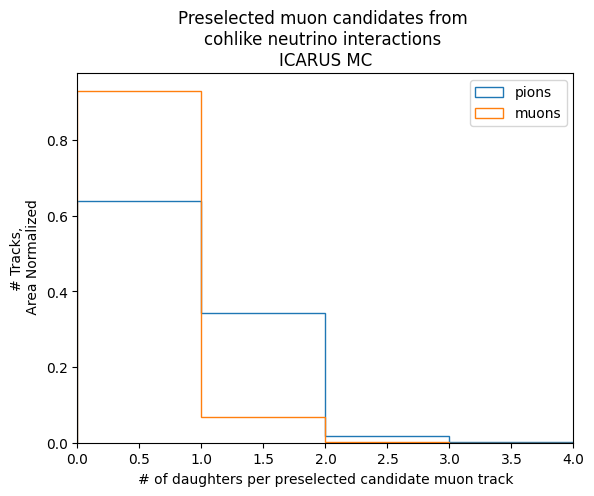

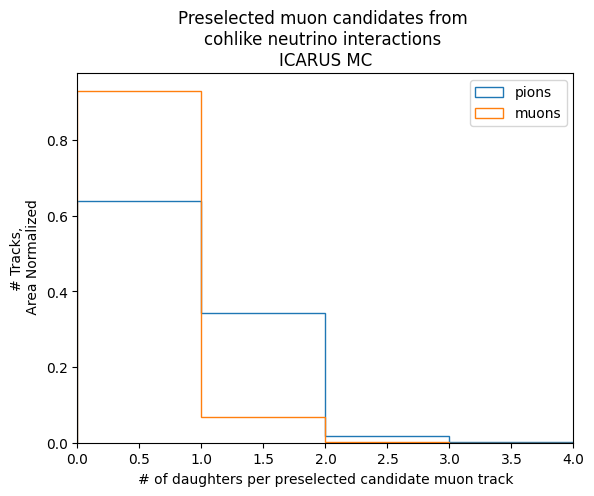

In [20]:
# n daughters
mupi_plot(evtdf_wWgts,
          evtdf_wWgts.trunk.ndaughters,
          evtdf_wWgts.branch.ndaughters,
          (0,4),
          mybins=4,
          myDensity=True,
          xlabel='# of daughters per preselected candidate muon track',
          title='Preselected muon candidates from \ncohlike neutrino interactions \nICARUS MC',
          #title='Trunk and branch trks from preselected cohlike neutrino events',
          onlyLong = False
         )

min, max for pions: 0.34768113, 6626.7266
min, max for muons: 0.35492226, 891.0367


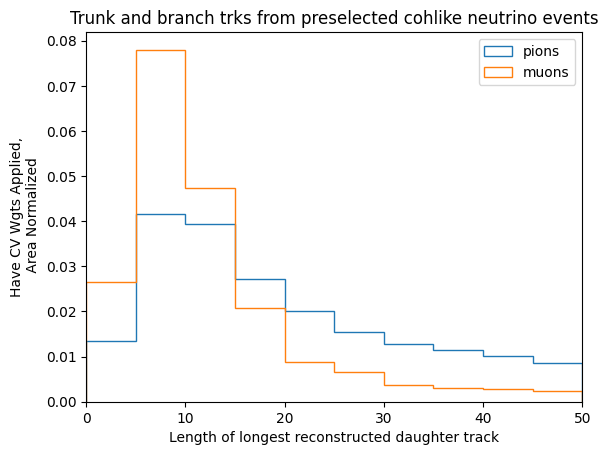

In [17]:
# longest daughter length
mupi_plot(evtdf_wWgts, 
          evtdf_wWgts.trunk.longest_daughter_length, 
          evtdf_wWgts.branch.longest_daughter_length, 
          (0,50), 
          mybins=10, 
          myDensity=True, 
          xlabel='Length of longest reconstructed daughter track',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )


min, max for pions: nan, nan
min, max for muons: nan, nan


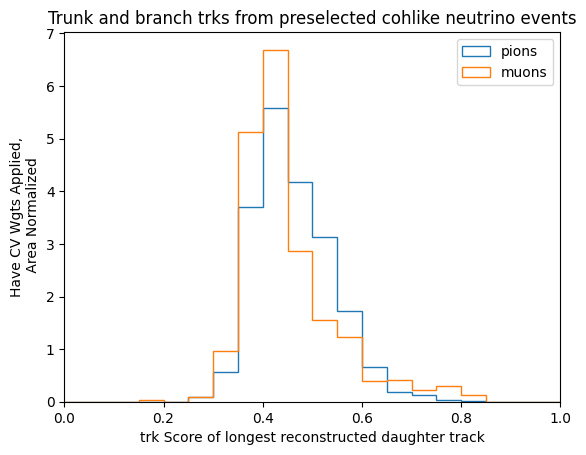

In [43]:
# longest daughter track score
mupi_plot(evtdf_wWgts,
          evtdf_wWgts.trunk.longest_daughter_trkScore, 
          evtdf_wWgts.branch.longest_daughter_trkScore, 
          (0,1),
          mybins=20,
          myDensity=True, 
          xlabel='trk Score of longest reconstructed daughter track',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )


In [90]:
# longest daughter start point distance from track START point.

def process_row(row, branch=False):
    if branch:
        x = distance_3d(np.array((float(row.trunk.trk.start.x), 
                         float(row.trunk.trk.start.y),
                         float(row.trunk.trk.start.z)
                        )), 
                        np.array((float(row.trunk.longest_daughter_start_x),
                         float(row.trunk.longest_daughter_start_y),
                         float(row.trunk.longest_daughter_start_z)
                        ))
                       )
    else:
        x = distance_3d(np.array((float(row.trunk.trk.start.x), 
                         float(row.trunk.trk.start.y),
                         float(row.trunk.trk.start.z)
                        )), 
                        np.array((float(row.trunk.longest_daughter_start_x),
                         float(row.trunk.longest_daughter_start_y),
                         float(row.trunk.longest_daughter_start_z)
                        ))
                       )
    return x

trunk_var = evtdf_wWgts.apply(process_row, axis=1)
branch_var = evtdf_wWgts.apply(process_row, axis=1, branch=True)

min, max for pions: 3.8087803414988137, 786.8665026289041
min, max for muons: 2.364943326574176, 786.8665026289041


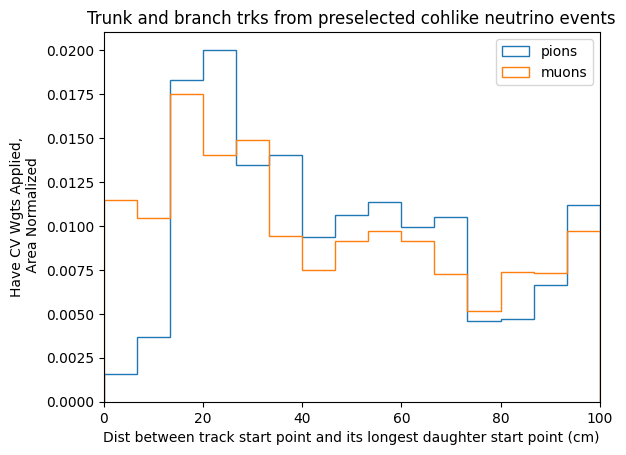

In [91]:
mupi_plot(evtdf_wWgts, 
          trunk_var, 
          branch_var, 
          (0,100), 
          mybins=15, 
          myDensity=True, 
          xlabel='Dist between track start point and its longest daughter start point (cm)',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )

min, max for pions: 0.1295770035547212, 455.140322441757
min, max for muons: 0.1295770035547212, 455.140322441757


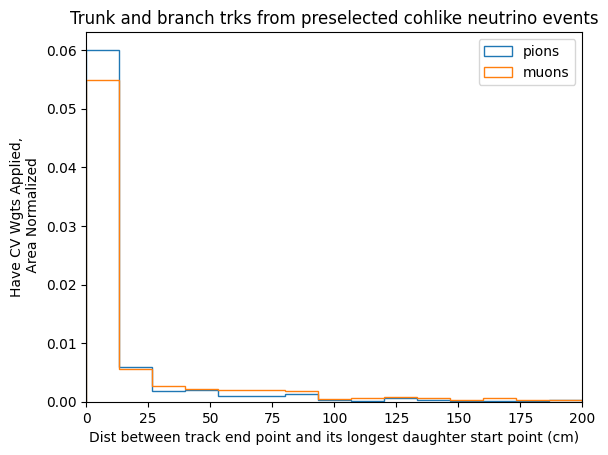

In [84]:
# longest daughter start point distance from track END point.

def process_row(row, branch=False):
    if branch:
        x = distance_3d(np.array((float(row.trunk.trk.end.x), 
                         float(row.trunk.trk.end.y),
                         float(row.trunk.trk.end.z)
                        )), 
                        np.array((float(row.trunk.longest_daughter_start_x),
                         float(row.trunk.longest_daughter_start_y),
                         float(row.trunk.longest_daughter_start_z)
                        ))
                       )
    else:
        x = distance_3d(np.array((float(row.trunk.trk.end.x), 
                         float(row.trunk.trk.end.y),
                         float(row.trunk.trk.end.z)
                        )), 
                        np.array((float(row.trunk.longest_daughter_start_x),
                         float(row.trunk.longest_daughter_start_y),
                         float(row.trunk.longest_daughter_start_z)
                        ))
                       )
    return x

trunk_var = evtdf_wWgts.apply(process_row, axis=1)
branch_var = evtdf_wWgts.apply(process_row, axis=1, branch=True)



min, max for pions: 0.1295770035547212, 455.140322441757
min, max for muons: 0.1295770035547212, 455.140322441757


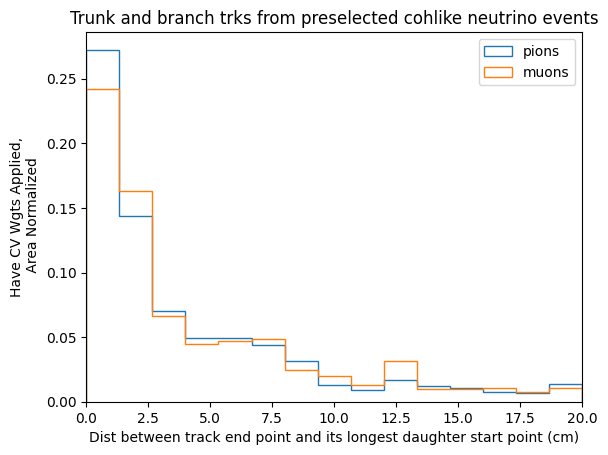

In [86]:
mupi_plot(evtdf_wWgts, 
          trunk_var, 
          branch_var, 
          (0,20), 
          mybins=15, 
          myDensity=True, 
          xlabel='Dist between track end point and its longest daughter start point (cm)',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )

min, max for pions: 0.11008445, 155.75255
min, max for muons: 0.050786678, 173.95482


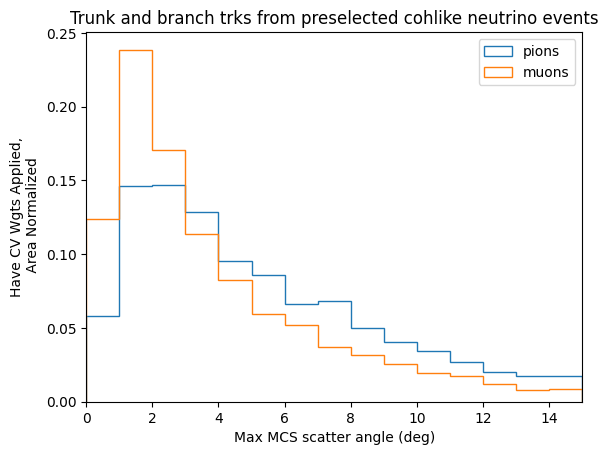

In [87]:
# max MCS angle
mupi_plot(evtdf_wWgts, 
          evtdf_wWgts.trunk.trk.mcsP.max_angle, 
          evtdf_wWgts.branch.trk.mcsP.max_angle, 
          (0,15), 
          mybins=15, 
          myDensity=True, 
          xlabel='Max MCS scatter angle (deg)',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )

min, max for pions: 0.11008445, 89.49687
min, max for muons: 0.03855766, 65.888626


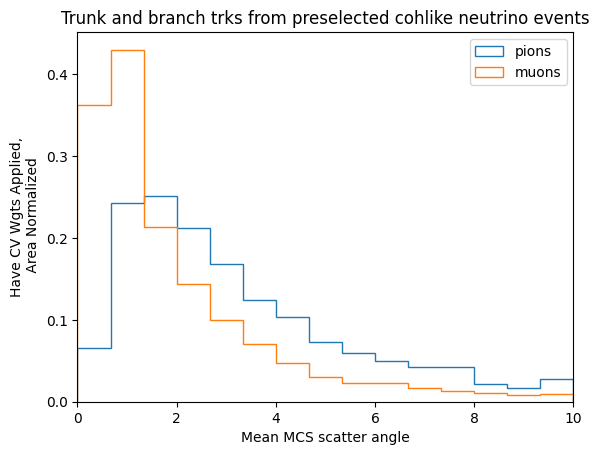

In [45]:
# mean MCS angle
mupi_plot(evtdf_wWgts, 
          evtdf_wWgts.trunk.trk.mcsP.mean_angle, 
          evtdf_wWgts.branch.trk.mcsP.mean_angle, 
          (0,10), 
          mybins=15, 
          myDensity=True, 
          xlabel='Mean MCS scatter angle',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )

min, max for pions: 0.000935565631460445, 54.62384547426673
min, max for muons: 1.0895742466005018e-05, 58.79189723342891


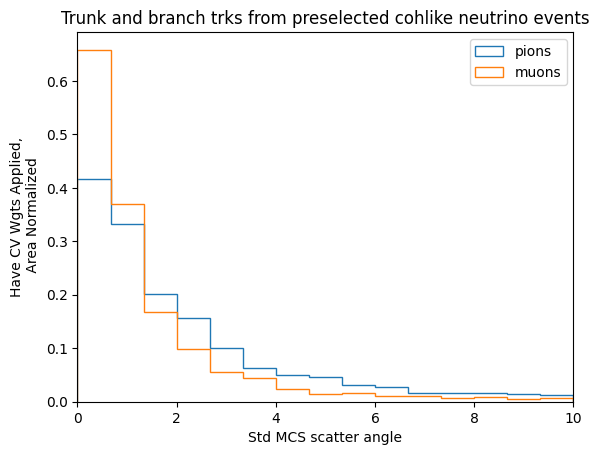

In [46]:
# std MCS angle
mupi_plot(evtdf_wWgts, 
          evtdf_wWgts.trunk.trk.mcsP.std_angle, 
          evtdf_wWgts.branch.trk.mcsP.std_angle, 
          (0,10), 
          mybins=15, 
          myDensity=True, 
          xlabel='Std MCS scatter angle',
          title='Trunk and branch trks from preselected cohlike neutrino events', 
          onlyLong = False
         )

min, max for pions: 0.5674115026145793, 4.467193215885341
min, max for muons: 0.5465015708915474, 6.822084354685474


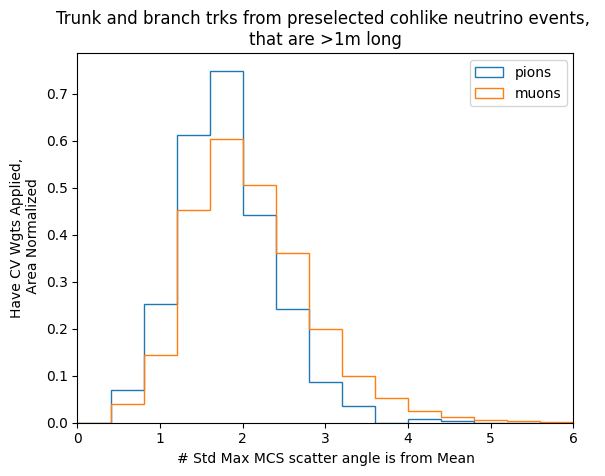

In [89]:
trunk_var = (evtdf_wWgts.trunk.trk.mcsP.max_angle - evtdf_wWgts.trunk.trk.mcsP.mean_angle)/evtdf_wWgts.trunk.trk.mcsP.std_angle
branch_var = (evtdf_wWgts.branch.trk.mcsP.max_angle - evtdf_wWgts.branch.trk.mcsP.mean_angle)/evtdf_wWgts.branch.trk.mcsP.std_angle
evtdf_wWgts.branch.trk.mcsP["nStdMax"] = (evtdf_wWgts.branch.trk.mcsP.max_angle - evtdf_wWgts.branch.trk.mcsP.mean_angle)/evtdf_wWgts.branch.trk.mcsP.std_angle
mupi_plot(evtdf_wWgts, 
          trunk_var,
          branch_var,
          (0,6.), #(0.6,0.8), 
          mybins=15, 
          myDensity=True, 
          xlabel='# Std Max MCS scatter angle is from Mean',
          title='Trunk and branch trks from preselected cohlike neutrino events',  #\nWhy so many events at 0.7071???
          onlyLong = True
         )


In [30]:
mask = (round(trunk_var*10000.)/10000. == 0.7071) # ((trunk_var > 0.6 ) & (trunk_var < 0.8))
print(trunk_var[mask])
print(evtdf_wWgts.trunk.trk.mcsP.max_angle[mask])
print(evtdf_wWgts.trunk.trk.mcsP.mean_angle[mask])
print(evtdf_wWgts.trunk.trk.mcsP.std_angle[mask])


__ntuple  entry  rec.slc..index
18        10     1                 0.707101
          27     23                0.707106
          30     21                0.707107
          35     0                 0.707107
19        39     13                0.707107
                                     ...   
791       13     1                 0.707107
          37     15                0.707107
797       6      0                 0.707107
          10     23                0.707106
          31     12                0.707107
Length: 1051, dtype: float64
__ntuple  entry  rec.slc..index
18        10     1                  2.051822
          27     23                 1.000768
          30     21                 8.275900
          35     0                  1.168189
19        39     13                20.944883
                                     ...    
791       13     1                  7.499325
          37     15                13.820824
797       6      0                  2.221825
          10     2

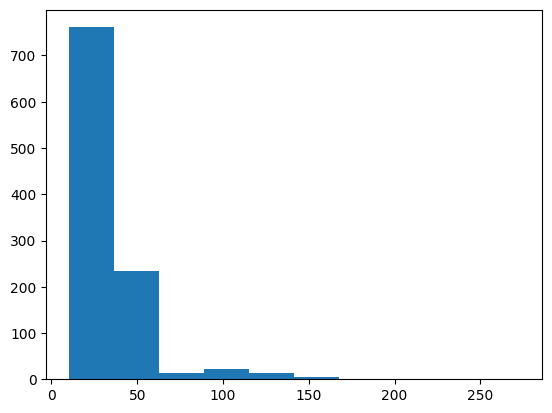

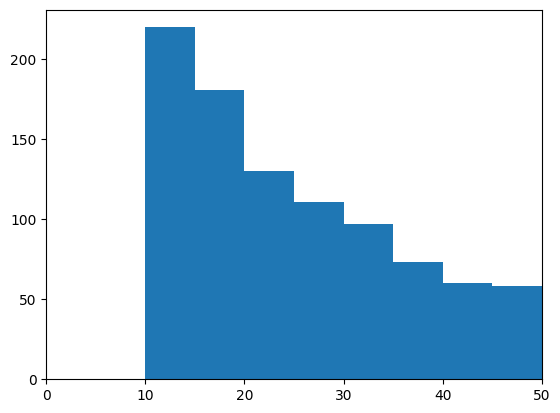

In [35]:
plt.hist(evtdf_wWgts[mask].trunk.trk.len)
plt.show()

myRange = (0,50)
plt.hist(evtdf_wWgts[mask].trunk.trk.len, range=myRange)
plt.xlim(myRange)
plt.show()

In [33]:
print(np.mean(trunk_var))
print(np.mean(branch_var))

1.83929054958839
1.3955213762134626


## end of study

## Make plots to see size and direction of flux uncertainties

In [2]:
# Contents of numisyst, since I can't import it from different directory:


In [6]:
#f = "/exp/icarus/data/users/jdyer/dimuon-data/2501_moreCohlike/more_Cohlike.df"
updated_df_dir = "/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/"
f = updated_df_dir+"cohlike-F-1.df"
mcdf = pd.read_hdf(f, key="mcnuwgt")


In [4]:

with h5py.File("/exp/icarus/data/users/jdyer/dimuon-data/2501_moreCohlike/more_Cohlike.df", 'r') as f:
    keys_list = list(f.keys())
    print(keys_list)


['evt', 'hdr', 'mch', 'mcnu', 'mcnuwgt']


In [7]:
beam_systematics = [ # the +1 sigma variations.
    "Beam_shift_x",
    "Beam_shift_y",
    "Beam_spot",
    "Horn1_x",
    "Horn1_y",
    "Horn2_x",
    "Horn2_y",
    "Horn_current",
    "Horn_water",
    "Target_z"
] + ["pca%i" % i for i in range(20)]

genie_systematics = [
    # CCQE
    "GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape",
    "GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE",
    "GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE",
    "GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse",

    # MEC
    "GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC",
    "GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC",
    "GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC",

    # RES
    "GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse",
    "GENIEReWeight_ICARUS_v2_multisim_NCRESVariationResponse",
    "GENIEReWeight_ICARUS_v2_multisigma_RDecBR1gamma",
    "GENIEReWeight_ICARUS_v2_multisigma_RDecBR1eta",
    "GENIEReWeight_ICARUS_v2_multisigma_Theta_Delta2Npi",
    "GENIEReWeight_ICARUS_v2_multisigma_ThetaDelta2NRad",

    # Non-Res
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpCC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvpNC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnCC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnNC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvnNC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarpCC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarpCC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarpNC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarpNC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarnCC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarnCC2pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarnNC1pi",
    "GENIEReWeight_ICARUS_v2_multisigma_NonRESBGvbarnNC2pi",
    
    # DIS
    "GENIEReWeight_ICARUS_v2_multisim_DISBYVariationResponse",

    # COH
    # "GENIEReWeight_ICARUS_v2_multisigma_NormCCCOH", # handled by tuning
    "GENIEReWeight_ICARUS_v2_multisigma_NormNCCOH",

    # FSI
    "GENIEReWeight_ICARUS_v2_multisim_FSI_pi_VariationResponse",
    "GENIEReWeight_ICARUS_v2_multisim_FSI_N_VariationResponse",

    # NCEL
    "GENIEReWeight_ICARUS_v2_multisim_NCELVariationResponse",
]

g4_systematics = [
    "reinteractions_piminus_Geant4",
    "reinteractions_piplus_Geant4",
    "reinteractions_proton_Geant4"
]

systematics = beam_systematics + genie_systematics + g4_systematics
for c in mcdf.columns:
    if c[0] in systematics:
        print(c)

('Beam_shift_x', 'actual_ps1', '')
('Beam_shift_x', 'actual_ms1', '')
('Beam_shift_x', 'ps1', '')
('Beam_shift_x', 'ms1', '')
('Beam_shift_y', 'actual_ps1', '')
('Beam_shift_y', 'actual_ms1', '')
('Beam_shift_y', 'ps1', '')
('Beam_shift_y', 'ms1', '')
('Beam_spot', 'actual_ps1', '')
('Beam_spot', 'actual_ms1', '')
('Beam_spot', 'ps1', '')
('Beam_spot', 'ms1', '')
('Horn1_x', 'actual_ps1', '')
('Horn1_x', 'actual_ms1', '')
('Horn1_x', 'ps1', '')
('Horn1_x', 'ms1', '')
('Horn1_y', 'actual_ps1', '')
('Horn1_y', 'actual_ms1', '')
('Horn1_y', 'ps1', '')
('Horn1_y', 'ms1', '')
('Horn2_x', 'actual_ps1', '')
('Horn2_x', 'actual_ms1', '')
('Horn2_x', 'ps1', '')
('Horn2_x', 'ms1', '')
('Horn2_y', 'actual_ps1', '')
('Horn2_y', 'actual_ms1', '')
('Horn2_y', 'ps1', '')
('Horn2_y', 'ms1', '')
('Horn_current', 'actual_ps1', '')
('Horn_current', 'actual_ms1', '')
('Horn_current', 'ps1', '')
('Horn_current', 'ms1', '')
('Horn_water', 'actual_ps1', '')
('Horn_water', 'actual_ms1', '')
('Horn_water', 'ps

In [12]:
for s in systematics:
    print('s: ', s)
    if s not in mcdf.columns: 
        print('Cant find systematic called %a in df. Fix this!!' %s)
        continue

    # +/-1 sigma
    if 'ps' in mcdf[s].columns[0][0]: #.startswith("ps"): # JD October 30, 2025
        #print('mcdf[s].columns: ', mcdf[s].columns)
        ps = mcdf[s].columns[0][0]
        print(ps)
        

s:  Beam_shift_x
actual_ps1
s:  Beam_shift_y
actual_ps1
s:  Beam_spot
actual_ps1
s:  Horn1_x
actual_ps1
s:  Horn1_y
actual_ps1
s:  Horn2_x
actual_ps1
s:  Horn2_y
actual_ps1
s:  Horn_current
actual_ps1
s:  Horn_water
actual_ps1
s:  Target_z
actual_ps1
s:  pca0
ps1
s:  pca1
ps1
s:  pca2
ps1
s:  pca3
ps1
s:  pca4
ps1
s:  pca5
ps1
s:  pca6
ps1
s:  pca7
ps1
s:  pca8
ps1
s:  pca9
ps1
s:  pca10
ps1
s:  pca11
ps1
s:  pca12
ps1
s:  pca13
ps1
s:  pca14
ps1
s:  pca15
ps1
s:  pca16
ps1
s:  pca17
ps1
s:  pca18
ps1
s:  pca19
ps1
s:  GENIEReWeight_ICARUS_v2_multisigma_VecFFCCQEshape
s:  GENIEReWeight_ICARUS_v2_multisigma_RPA_CCQE
ps1
s:  GENIEReWeight_ICARUS_v2_multisigma_CoulombCCQE
ps1
s:  GENIEReWeight_ICARUS_v2_multisim_ZExpAVariationResponse
s:  GENIEReWeight_ICARUS_v2_multisigma_NormCCMEC
ps1
s:  GENIEReWeight_ICARUS_v2_multisigma_NormNCMEC
ps1
s:  GENIEReWeight_ICARUS_v2_multisigma_DecayAngMEC
s:  GENIEReWeight_ICARUS_v2_multisim_CCRESVariationResponse
s:  GENIEReWeight_ICARUS_v2_multisim_NCRE

At this point (reading in my basic dataframe), mcdf already has the flux systematics that Gray had used. That is because the mcnuwgt dataframe is made according to numisyst, so at the time this dataframe was made, it had Gray's version of numisyst.

In [68]:
mcdf.beam_shift_x



ps1       ms1
                                                   
__ntuple entry rec.mc.nu..index                    
3        0     0                 1.014472  0.985528
         1     0                 1.016031  0.983969
         2     0                 1.014748  0.985252
         3     0                 1.030982  0.969018
               1                 1.008906  0.991094
...                                   ...       ...
4536     49    0                 1.018187  0.981813
         50    0                 1.016387  0.983613
         51    0                 1.016782  0.983218
         52    0                 1.016852  0.983148
         53    0                 1.016852  0.983148

[280634 rows x 2 columns]

In [3]:
for c in mcdf.columns: print(c)
    

('E', '', '')
('time', '', '')
('bjorkenX', '', '')
('inelasticityY', '', '')
('Q2', '', '')
('w', '', '')
('momentum', 'x', '')
('momentum', 'y', '')
('momentum', 'z', '')
('position', 'x', '')
('position', 'y', '')
('position', 'z', '')
('pdg', '', '')
('iscc', '', '')
('genie_mode', '', '')
('parent_pdg', '', '')
('parent_dcy_E', '', '')
('max_proton_ke', '', '')
('nn', '', '')
('np', '', '')
('nmu', '', '')
('npi', '', '')
('npi0', '', '')
('ng', '', '')
('nk', '', '')
('nk0', '', '')
('nsm', '', '')
('nsp', '', '')
('p0', 'genE', '')
('p0', 'pdg', '')
('p0', 'genp', 'x')
('p0', 'genp', 'y')
('p0', 'genp', 'z')
('p0', 'start', 'x')
('p0', 'start', 'y')
('p0', 'start', 'z')
('p0', 'end', 'x')
('p0', 'end', 'y')
('p0', 'end', 'z')
('p1', 'genE', '')
('p1', 'pdg', '')
('p1', 'genp', 'x')
('p1', 'genp', 'y')
('p1', 'genp', 'z')
('p1', 'start', 'x')
('p1', 'start', 'y')
('p1', 'start', 'z')
('p1', 'end', 'x')
('p1', 'end', 'y')
('p1', 'end', 'z')
('ind', '', '')
('ppfx', 'cv', '')
('bea

In [5]:
print(np.max(np.abs(1-mcdf.horn1_x.ps1) - np.abs(1-mcdf.horn1_x.ms1))) # basically zero as expected.



1.1102230246251565e-16


In [ ]:
# run the contents of numisyst in below cell since I can't import it from other directory.

In [35]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#FSYST = "/exp/icarus/data/users/gputnam/thesis-work/icarus_numi_flux_syst_ana_v2.root"
FSYST = "/pnfs/icarus/persistent/users/faabdalr/2025-04-08_out_450.37_7991.98_79512.66.root" # change made June 12, 2025 to update to most recent flux weights from Fatima and Dan. This change takes care of the ppfx weights. (See notes saved to my desktop in muons_analysis folder titled 250611_flux_wgt_update.)
FSYST = "/exp/icarus/app/users/jdyer/2025-04-08_out_450.37_7991.98_79512.66.root" # This is a copy of above, that I can access.

# original
#beam_uncertainties = [
#    "beam_div",
#    "beam_shift_x",
#    "beam_spot",
#    "horn1_x",
#    "horn1_y",
#    "horn_current_plus",
#    "water_layer"
#    # Question 6/20/25: is there a reason Gray didn't include the beam_shift_y ones that are also in the file?
#    # My guessed answer: because all the other ones were applied as symmetric +- variations, but the y ones have specific + and -. 
#] 

# Question: why didn't Gray include hadron production uncertainties? It existed in FSYST file --> fractional_uncertainties --> hadron. Answer: the pca is accounting for the hadron uncertainties and can be used instead of the stuff labeled "hadron" in the file (says Gray.)

# Jamie update 6/20/25:
focusing_uncertainties_names = [ # the +1 sigma variations.
    "Beam_shift_x",
    "Beam_shift_y",
    "Beam_spot",
    "Horn1_x",
    "Horn1_y",
    "Horn2_x",
    "Horn2_y",
    "Horn_current",
    "Horn_water",
    "Target_z"
]

ps1_focusing_uncertainties = [ # the +1 sigma variations.
    "Beam_shift_x_p1mm",
    "Beam_shift_y_p1mm",
    "Beam_spot_1_7mm",
    "Horn1_x_p3mm",
    "Horn1_y_p3mm",
    "Horn2_x_p3mm",
    "Horn2_y_p3mm",
    "Horn_p2kA",
    "Horns_2mm_water",
    "Target_z_p7mm"
]
ms1_focusing_uncertainties = [ # the -1 sigma variations.
    "Beam_shift_x_m1mm",
    "Beam_shift_y_m1mm",
    "Beam_spot_1_3mm",
    "Horn1_x_m3mm",
    "Horn1_y_m3mm",
    "Horn2_x_m3mm",
    "Horn2_y_m3mm",
    "Horn_m2kA",
    "Horns_0mm_water",
    "Target_z_m7mm"
]

pca_components = list(range(20))

def histdf(h):
    values = h.values()
    bins = h.axis().edges()
    idx = pd.IntervalIndex.from_breaks(bins)
    return pd.Series(values, idx, name=None)
           
def getallpdg_histdf(d, prefix):
    pdgs = {
        "numu": 14,
        "numubar": -14,
        "nue": 12,
        "nuebar": -12   
    }
    hs = []
    for pdgname, pdgcode in pdgs.items():
        h = histdf(d[prefix + pdgname])
        h.index = pd.MultiIndex.from_product([[pdgcode], h.index], names=["pdg", "E"])
        hs.append(h)
    return pd.concat(hs)

def numisyst(nupdg, nuE, fsyst=FSYST, symmetrize_errBars=True):
    flux_f = uproot.open(fsyst)

    cv = getallpdg_histdf(flux_f["ppfx_flux_weights"], "hweights_fhc_")
    cv.name = ("ppfx", "cv")

    beam_syst_wgts = []
    
    ## original:
    #for uc in beam_uncertainties:
    #    uncdf = getallpdg_histdf(flux_f["fractional_uncertainties"]["beam"][uc], "hfrac_beam_" + uc + "_fhc_")
    #    wgtdf_p = 1 + uncdf
    #    wgtdf_m = 1 - uncdf # JD June 30, 2025: I think this is/was the wrong way to do this! But I also don't think wgtdf_m ever got referenced. Nvm, it's fine.
    #    wgtdf_p.name = (uc, "ps1")
    #    wgtdf_m.name = (uc, "ms1")
    #    beam_syst_wgts.append(wgtdf_p)
    #    beam_syst_wgts.append(wgtdf_m)
    
    # Jamie update 6/20/25:
    for iuc, uc in enumerate(focusing_uncertainties_names):
        uncdf_p = getallpdg_histdf(flux_f["beam_focusing_uncertainties"]["fhc"], "hsyst_beam_" + ps1_focusing_uncertainties[iuc] + "_fhc_")
        uncdf_m = getallpdg_histdf(flux_f["beam_focusing_uncertainties"]["fhc"], "hsyst_beam_" + ms1_focusing_uncertainties[iuc] + "_fhc_")
        if symmetrize_errBars:
            uncdf = (np.abs(uncdf_p) + np.abs(uncdf_m))/2. # take the average b/c the covariance matrix requires symmetric uncertainties.
            #(Note: the "plus" and "minus" refer to the knobs, not the direction of event rate change. So distinguising between plus and minus is arbitrary anyway -- average should be totally fine.)
            wgtdf_p = 1 + uncdf
            wgtdf_m = 1 - uncdf # consider the "negative" knob turn to be the opposite sign change to the flux as the "positive" knob turn.
            # also save the actual ones for studying downstream:
            wgtdf_pActual = 1 + uncdf_p
            wgtdf_mActual = 1 + uncdf_m
            wgtdf_pActual.name = (uc, "actual_ps1")
            wgtdf_mActual.name = (uc, "actual_ms1")
            beam_syst_wgts.append(wgtdf_pActual)
            beam_syst_wgts.append(wgtdf_mActual)
        else: # note: if running this else, I need to figure something other than the covariance matrix out.
            wgtdf_p = 1 + uncdf_p
            wgtdf_m = 1 + uncdf_m
        wgtdf_p.name = (uc, "ps1")
        wgtdf_m.name = (uc, "ms1")
        beam_syst_wgts.append(wgtdf_p)
        beam_syst_wgts.append(wgtdf_m)
    
    for i in pca_components: # note: the PCA components account for the hadron production uncertainties.
        uncdf = getallpdg_histdf(flux_f["pca"]["principal_components"], "hpc_%i_fhc_" % i)
        wgtdf_p = 1 + uncdf
        wgtdf_m = 1 - uncdf
        wgtdf_p.name = (("pca%i" % i), "ps1")
        wgtdf_m.name = (("pca%i" % i), "ms1")
        beam_syst_wgts.append(wgtdf_p)
        beam_syst_wgts.append(wgtdf_m)

    wgts = pd.DataFrame([cv] + beam_syst_wgts).T
    nuind = pd.MultiIndex.from_arrays([nupdg, nuE])
    iloc = wgts.index.get_indexer(nuind)
    match_wgts = wgts.iloc[iloc]
    match_wgts.loc[iloc < 0, :] = 1.
    match_wgts.index = nupdg.index 

    return match_wgts




In [5]:
test = numisyst(mcdf.pdg, mcdf.E)


In [69]:
print(np.max(np.abs(1-test.Horn1_x_p3mm.ps1) - np.abs(1-test.Horn1_x_p3mm.ms1))) # Not basically zero, as expected, because I didn't symmetrize these. 

0.10809233858714795


In [37]:
for c in test.columns: print(c)


('ppfx', 'cv')
('Beam_shift_x', 'actual_ps1')
('Beam_shift_x', 'actual_ms1')
('Beam_shift_x', 'ps1')
('Beam_shift_x', 'ms1')
('Beam_shift_y', 'actual_ps1')
('Beam_shift_y', 'actual_ms1')
('Beam_shift_y', 'ps1')
('Beam_shift_y', 'ms1')
('Beam_spot', 'actual_ps1')
('Beam_spot', 'actual_ms1')
('Beam_spot', 'ps1')
('Beam_spot', 'ms1')
('Horn1_x', 'actual_ps1')
('Horn1_x', 'actual_ms1')
('Horn1_x', 'ps1')
('Horn1_x', 'ms1')
('Horn1_y', 'actual_ps1')
('Horn1_y', 'actual_ms1')
('Horn1_y', 'ps1')
('Horn1_y', 'ms1')
('Horn2_x', 'actual_ps1')
('Horn2_x', 'actual_ms1')
('Horn2_x', 'ps1')
('Horn2_x', 'ms1')
('Horn2_y', 'actual_ps1')
('Horn2_y', 'actual_ms1')
('Horn2_y', 'ps1')
('Horn2_y', 'ms1')
('Horn_current', 'actual_ps1')
('Horn_current', 'actual_ms1')
('Horn_current', 'ps1')
('Horn_current', 'ms1')
('Horn_water', 'actual_ps1')
('Horn_water', 'actual_ms1')
('Horn_water', 'ps1')
('Horn_water', 'ms1')
('Target_z', 'actual_ps1')
('Target_z', 'actual_ms1')
('Target_z', 'ps1')
('Target_z', 'ms1')
(

In [6]:
# Calculate the metrics

# Sign metric
# value = -1 : +&- knob turns have change flux in opposite directions.
# value = +1 : +&- knob turns have change flux in same direction.
mysign = np.sign( (1-test.Beam_shift_x.actual_ps1)*(1-test.Beam_shift_x.actual_ms1) )
test["Beam_shift_x",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Beam_shift_x","actual_ps1"]), abs(1-row["Beam_shift_x","actual_ms1"])]))
    bigger_wgt = np.max([row["Beam_shift_x","actual_ps1"], row["Beam_shift_x","actual_ms1"]])
    smaller_wgt = np.min([row["Beam_shift_x","actual_ps1"], row["Beam_shift_x","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Beam_shift_x",'scale_metric']=scale_metric
test["Beam_shift_x",'symm_metric']=symm_metric

mysign = np.sign( (1-test.Beam_shift_y.actual_ps1)*(1-test.Beam_shift_y.actual_ms1) )
test["Beam_shift_y",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Beam_shift_y","actual_ps1"]), abs(1-row["Beam_shift_y","actual_ms1"])]))
    bigger_wgt = np.max([row["Beam_shift_y","actual_ps1"], row["Beam_shift_y","actual_ms1"]])
    smaller_wgt = np.min([row["Beam_shift_y","actual_ps1"], row["Beam_shift_y","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Beam_shift_y",'scale_metric']=scale_metric
test["Beam_shift_y",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Beam_spot.actual_ps1)*(1-test.Beam_spot.actual_ms1) )
test["Beam_spot",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Beam_spot","actual_ps1"]), abs(1-row["Beam_spot","actual_ms1"])]))
    bigger_wgt = np.max([row["Beam_spot","actual_ps1"], row["Beam_spot","actual_ms1"]])
    smaller_wgt = np.min([row["Beam_spot","actual_ps1"], row["Beam_spot","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Beam_spot",'scale_metric']=scale_metric
test["Beam_spot",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Horn1_x.actual_ps1)*(1-test.Horn1_x.actual_ms1) )
test["Horn1_x",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Horn1_x","actual_ps1"]), abs(1-row["Horn1_x","actual_ms1"])]))
    bigger_wgt = np.max([row["Horn1_x","actual_ps1"], row["Horn1_x","actual_ms1"]])
    smaller_wgt = np.min([row["Horn1_x","actual_ps1"], row["Horn1_x","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Horn1_x",'scale_metric']=scale_metric
test["Horn1_x",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Horn1_y.actual_ps1)*(1-test.Horn1_y.actual_ms1) )
test["Horn1_y",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Horn1_y","actual_ps1"]), abs(1-row["Horn1_y","actual_ms1"])]))
    bigger_wgt = np.max([row["Horn1_y","actual_ps1"], row["Horn1_y","actual_ms1"]])
    smaller_wgt = np.min([row["Horn1_y","actual_ps1"], row["Horn1_y","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Horn1_y",'scale_metric']=scale_metric
test["Horn1_y",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Horn2_x.actual_ps1)*(1-test.Horn2_x.actual_ms1) )
test["Horn2_x",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Horn2_x","actual_ps1"]), abs(1-row["Horn2_x","actual_ms1"])]))
    bigger_wgt = np.max([row["Horn2_x","actual_ps1"], row["Horn2_x","actual_ms1"]])
    smaller_wgt = np.min([row["Horn2_x","actual_ps1"], row["Horn2_x","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Horn2_x",'scale_metric']=scale_metric
test["Horn2_x",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Horn2_y.actual_ps1)*(1-test.Horn2_y.actual_ms1) )
test["Horn2_y",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Horn2_y","actual_ps1"]), abs(1-row["Horn2_y","actual_ms1"])]))
    bigger_wgt = np.max([row["Horn2_y","actual_ps1"], row["Horn2_y","actual_ms1"]])
    smaller_wgt = np.min([row["Horn2_y","actual_ps1"], row["Horn2_y","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Horn2_y",'scale_metric']=scale_metric
test["Horn2_y",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Horn_current.actual_ps1)*(1-test.Horn_current.actual_ms1) )
test["Horn_current",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Horn_current","actual_ps1"]), abs(1-row["Horn_current","actual_ms1"])]))
    bigger_wgt = np.max([row["Horn_current","actual_ps1"], row["Horn_current","actual_ms1"]])
    smaller_wgt = np.min([row["Horn_current","actual_ps1"], row["Horn_current","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Horn_current",'scale_metric']=scale_metric
test["Horn_current",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Horn_water.actual_ps1)*(1-test.Horn_water.actual_ms1) )
test["Horn_water",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Horn_water","actual_ps1"]), abs(1-row["Horn_water","actual_ms1"])]))
    bigger_wgt = np.max([row["Horn_water","actual_ps1"], row["Horn_water","actual_ms1"]])
    smaller_wgt = np.min([row["Horn_water","actual_ps1"], row["Horn_water","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Horn_water",'scale_metric']=scale_metric
test["Horn_water",'symm_metric']=symm_metric


mysign = np.sign( (1-test.Target_z.actual_ps1)*(1-test.Target_z.actual_ms1) )
test["Target_z",'mysign']=mysign
scale_metric = []
symm_metric = []
for idx, row in test.iterrows():
    scale_metric.append(np.max([abs(1-row["Target_z","actual_ps1"]), abs(1-row["Target_z","actual_ms1"])]))
    bigger_wgt = np.max([row["Target_z","actual_ps1"], row["Target_z","actual_ms1"]])
    smaller_wgt = np.min([row["Target_z","actual_ps1"], row["Target_z","actual_ms1"]])
    symm_metric.append( (bigger_wgt-1) - (bigger_wgt-smaller_wgt)/2. )
test["Target_z",'scale_metric']=scale_metric
test["Target_z",'symm_metric']=symm_metric




In [48]:
# Calculate the metrics

# Sign metric
# value = -1 : +&- knob turns have change flux in opposite directions.
# value = +1 : +&- knob turns have change flux in same direction.
mysign = np.sign( (1-test.Beam_shift_x.actual_ps1)*(1-test.Beam_shift_x.actual_ms1) )
test["Beam_shift_x",'mysign']=mysign

mysign = np.sign( (1-test.Beam_shift_y.actual_ps1)*(1-test.Beam_shift_y.actual_ms1) )
test["Beam_shift_y",'mysign']=mysign

mysign = np.sign( (1-test.Beam_spot.actual_ps1)*(1-test.Beam_spot.actual_ms1) )
test["Beam_spot",'mysign']=mysign

mysign = np.sign( (1-test.Horn1_x.actual_ps1)*(1-test.Horn1_x.actual_ms1) )
test["Horn1_x",'mysign']=mysign

mysign = np.sign( (1-test.Horn1_y.actual_ps1)*(1-test.Horn1_y.actual_ms1) )
test["Horn1_y",'mysign']=mysign

mysign = np.sign( (1-test.Horn2_x.actual_ps1)*(1-test.Horn2_x.actual_ms1) )
test["Horn2_x",'mysign']=mysign

mysign = np.sign( (1-test.Horn2_y.actual_ps1)*(1-test.Horn2_y.actual_ms1) )
test["Horn2_y",'mysign']=mysign

mysign = np.sign( (1-test.Horn_current.actual_ps1)*(1-test.Horn_current.actual_ms1) )
test["Horn_current",'mysign']=mysign

mysign = np.sign( (1-test.Horn_water.actual_ps1)*(1-test.Horn_water.actual_ms1) )
test["Horn_water",'mysign']=mysign

mysign = np.sign( (1-test.Target_z.actual_ps1)*(1-test.Target_z.actual_ms1) )
test["Target_z",'mysign']=mysign




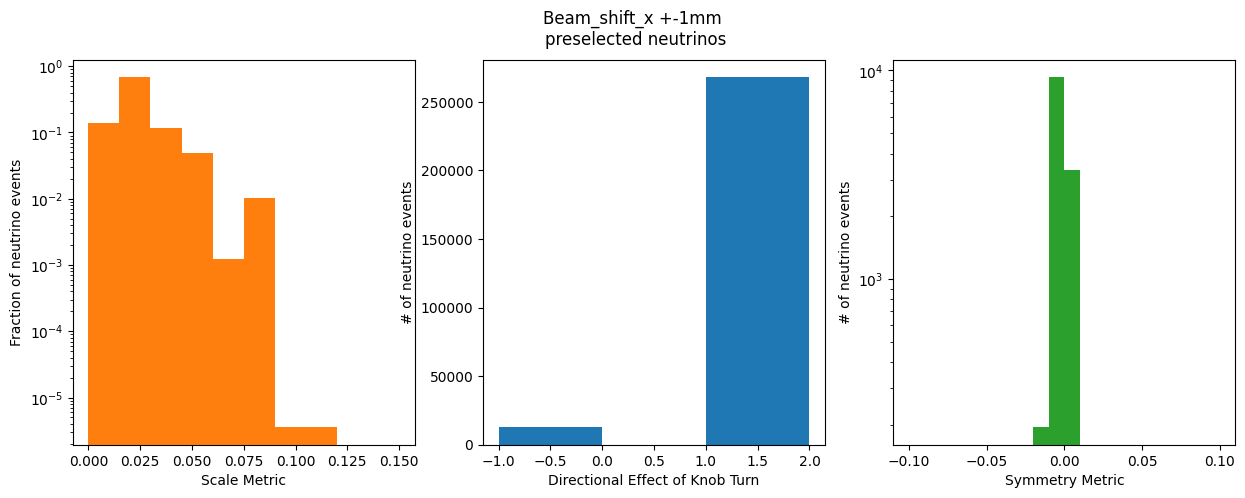

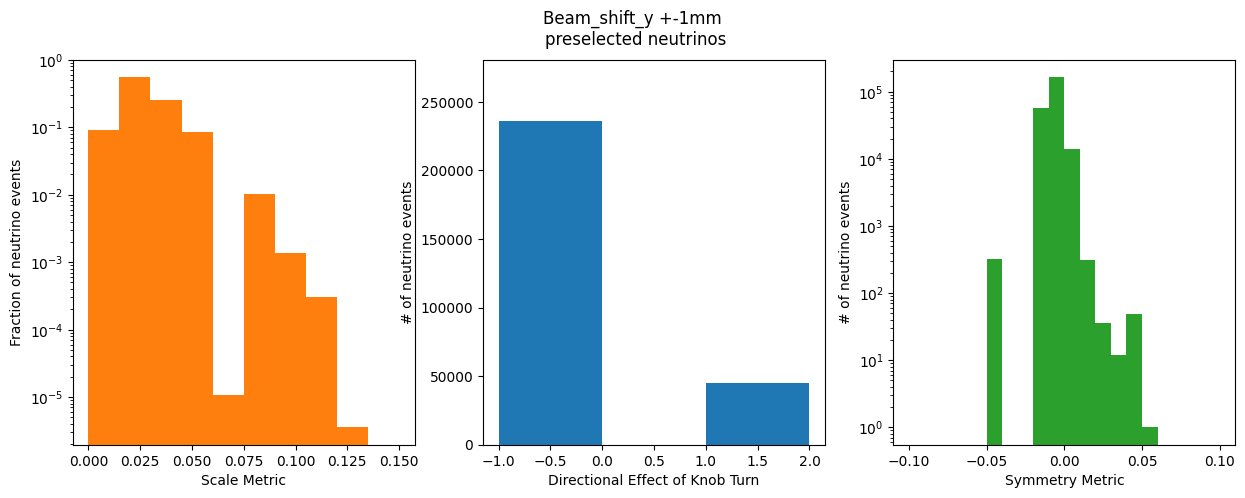

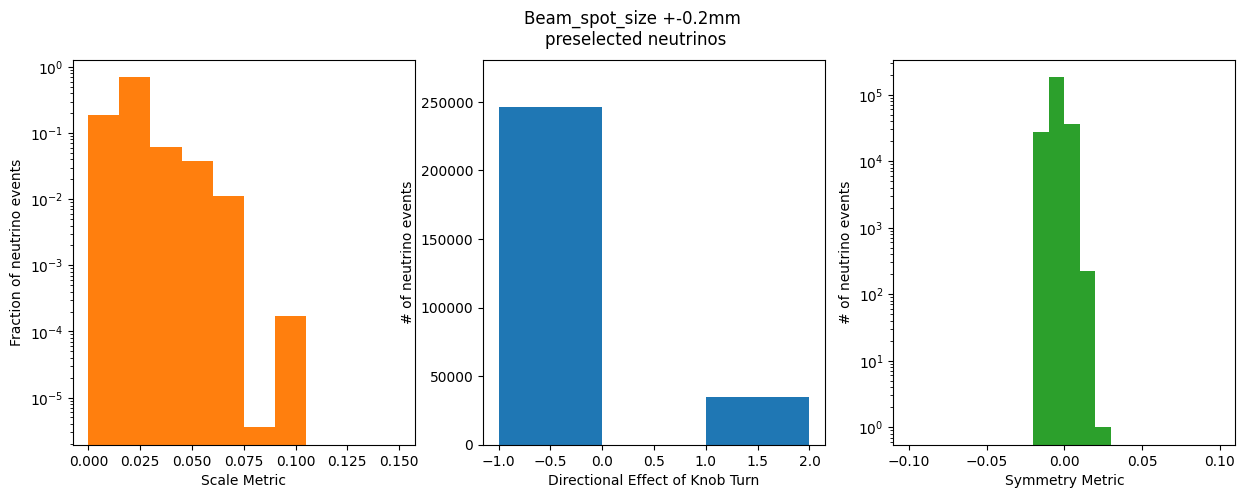

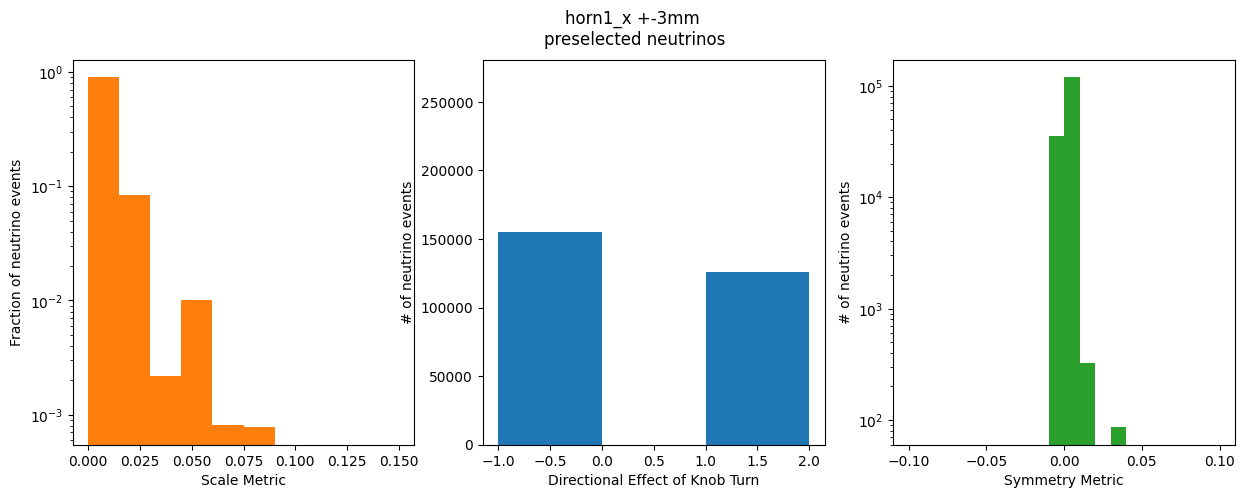

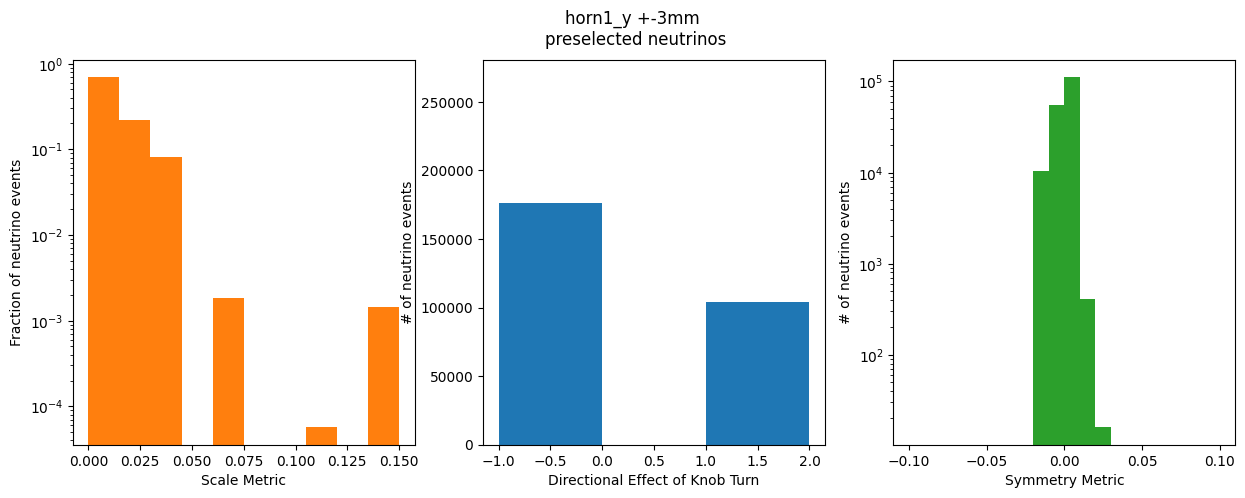

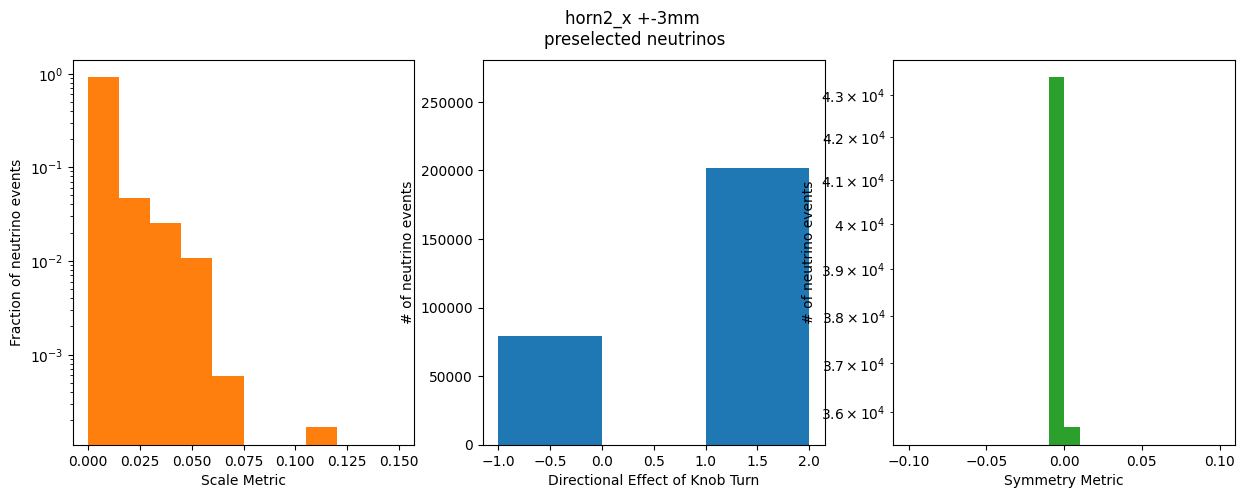

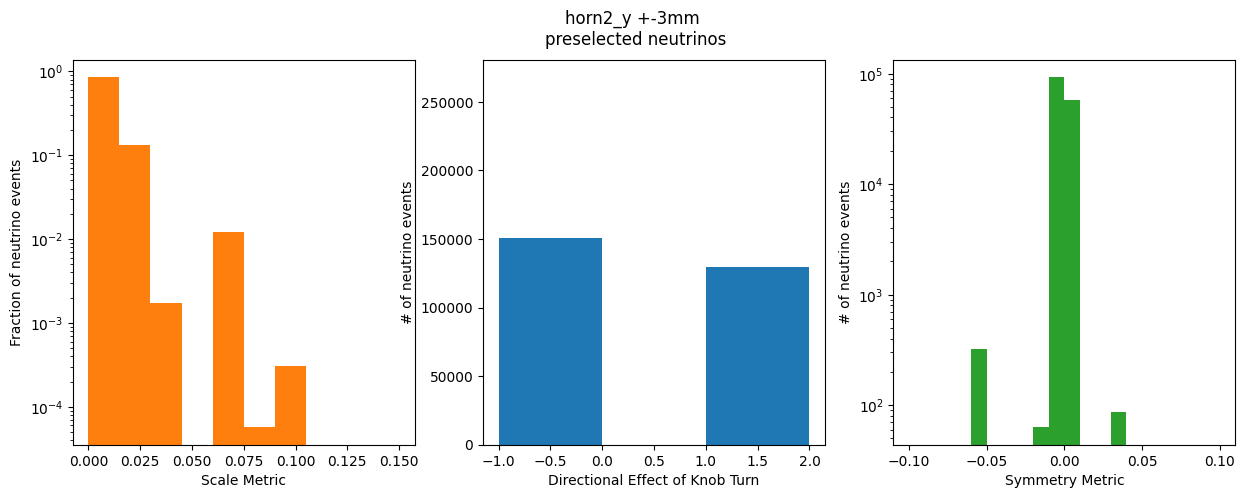

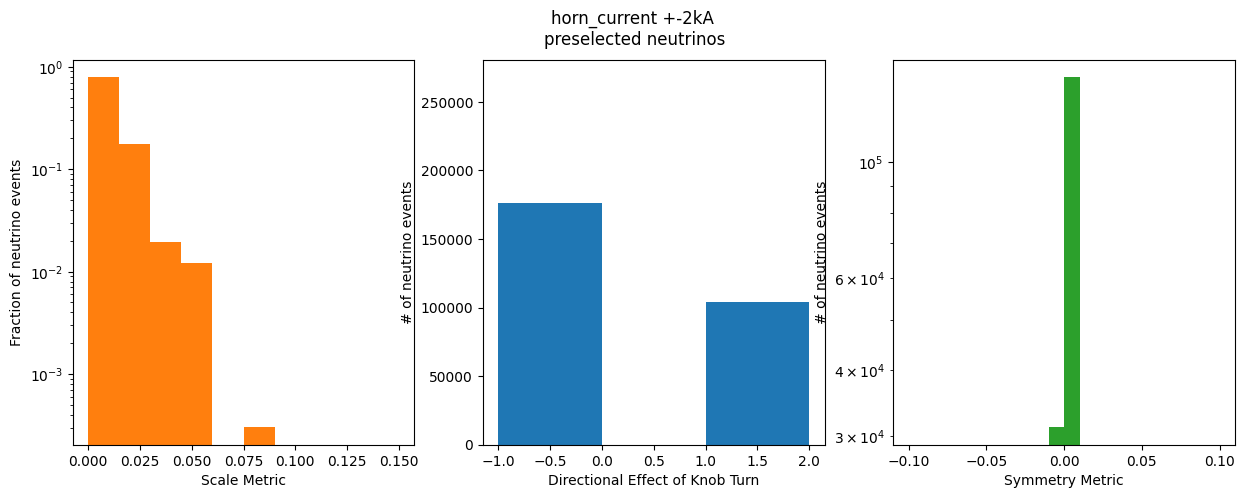

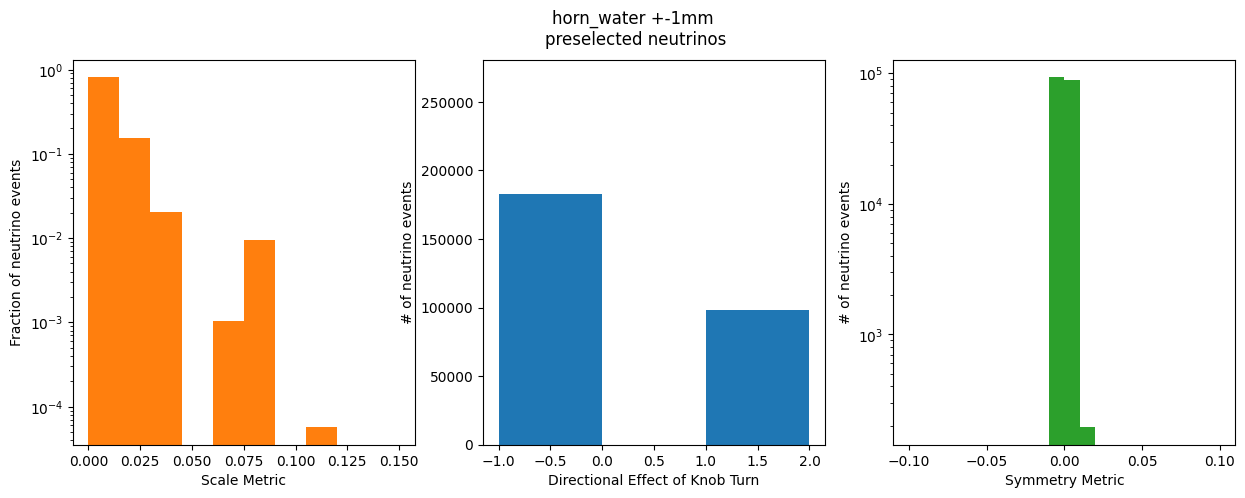

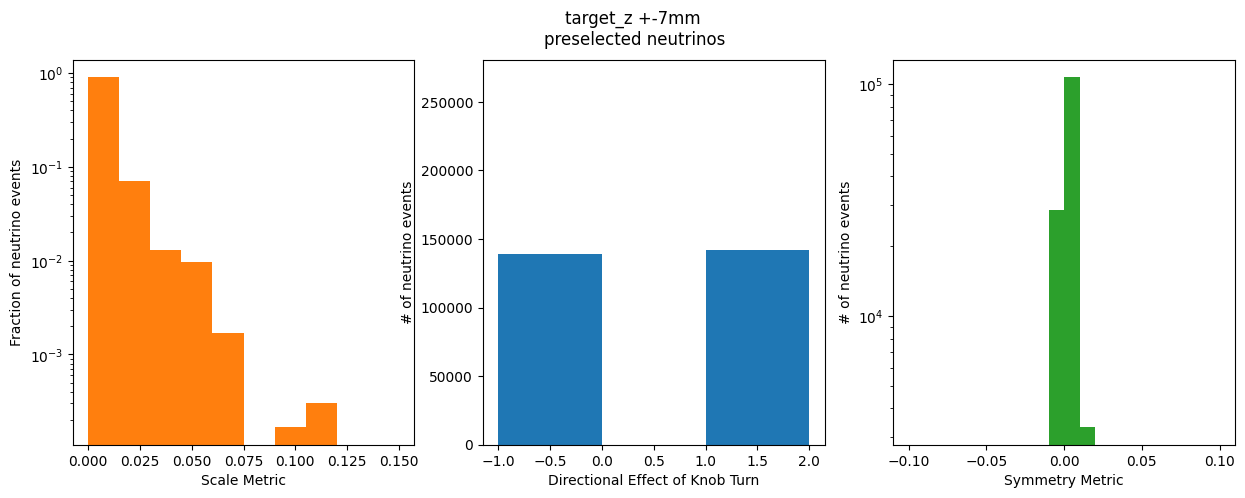

In [52]:
# Use subplots to make the plots for each systematic!

scalebins = 10
scaleRange = (0,0.15)
symmbins = 20
symmRange = (-0.10,0.10)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Beam_shift_x +-1mm \npreselected neutrinos')
ax1.hist(test["Beam_shift_x",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Beam_shift_x",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Beam_shift_x",'symm_metric'][test["Beam_shift_x",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Beam_shift_y +-1mm \npreselected neutrinos')
ax1.hist(test["Beam_shift_y",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Beam_shift_y",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Beam_shift_y",'symm_metric'][test["Beam_shift_y",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Beam_spot_size +-0.2mm \npreselected neutrinos')
ax1.hist(test["Beam_spot",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Beam_spot",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Beam_spot",'symm_metric'][test["Beam_spot",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('horn1_x +-3mm \npreselected neutrinos')
ax1.hist(test["Horn1_x",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Horn1_x",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Horn1_x",'symm_metric'][test["Horn1_x",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('horn1_y +-3mm \npreselected neutrinos')
ax1.hist(test["Horn1_y",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Horn1_y",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Horn1_y",'symm_metric'][test["Horn1_y",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('horn2_x +-3mm \npreselected neutrinos')
ax1.hist(test["Horn2_x",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Horn2_x",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Horn2_x",'symm_metric'][test["Horn2_x",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('horn2_y +-3mm \npreselected neutrinos')
ax1.hist(test["Horn2_y",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Horn2_y",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Horn2_y",'symm_metric'][test["Horn2_y",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('horn_current +-2kA \npreselected neutrinos')
ax1.hist(test["Horn_current",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Horn_current",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Horn_current",'symm_metric'][test["Horn_current",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('horn_water +-1mm \npreselected neutrinos')
ax1.hist(test["Horn_water",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Horn_water",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Horn_water",'symm_metric'][test["Horn_water",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('target_z +-7mm \npreselected neutrinos')
ax1.hist(test["Target_z",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins, range=scaleRange)
ax1.set(xlabel='Scale Metric', ylabel='Fraction of neutrino events', yscale='log')
ax2.hist(test["Target_z",'mysign'], bins=3, range=(-1,2))
ax2.set(xlabel='Directional Effect of Knob Turn', ylabel='# of neutrino events', ylim=(0,test.shape[0]))
ax3.hist(test["Target_z",'symm_metric'][test["Target_z",'mysign']<0], color='C2', bins=symmbins, range=symmRange)
ax3.set(xlabel='Symmetry Metric', ylabel='# of neutrino events', yscale='log')
#plt.xscale('log')
plt.show()

(280634, 92)
-1


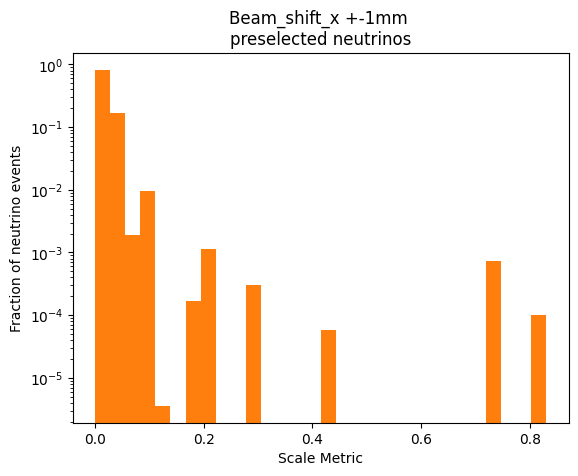

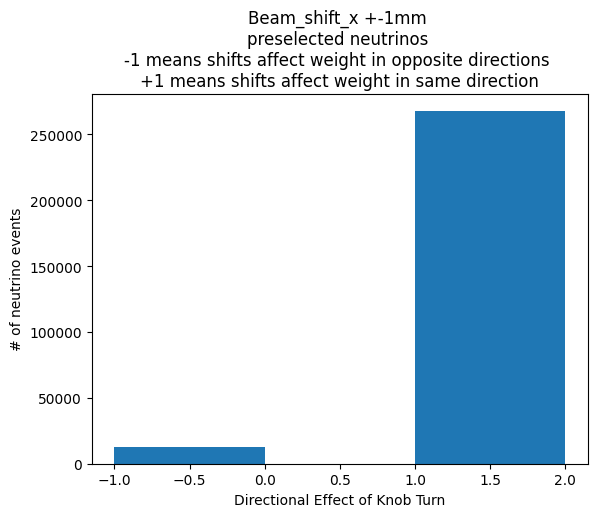

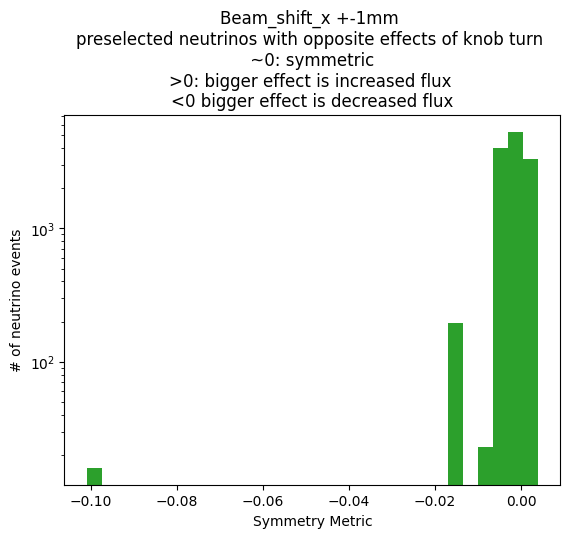

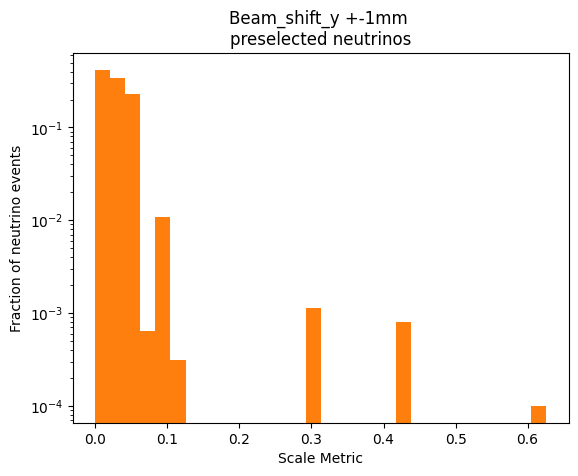

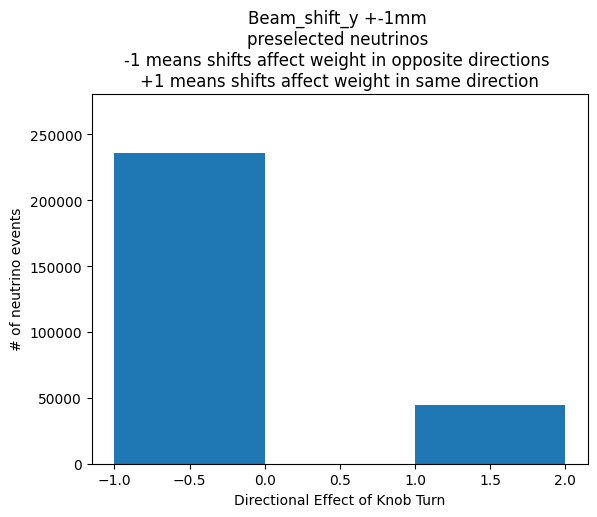

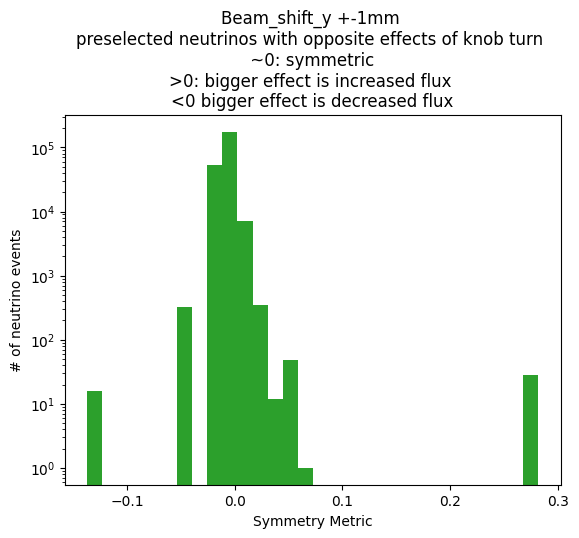

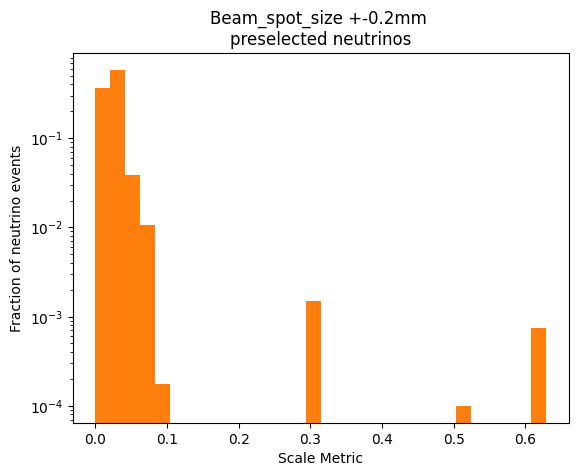

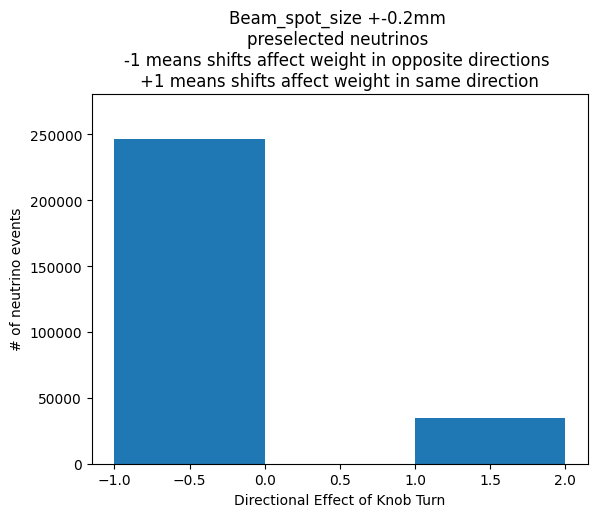

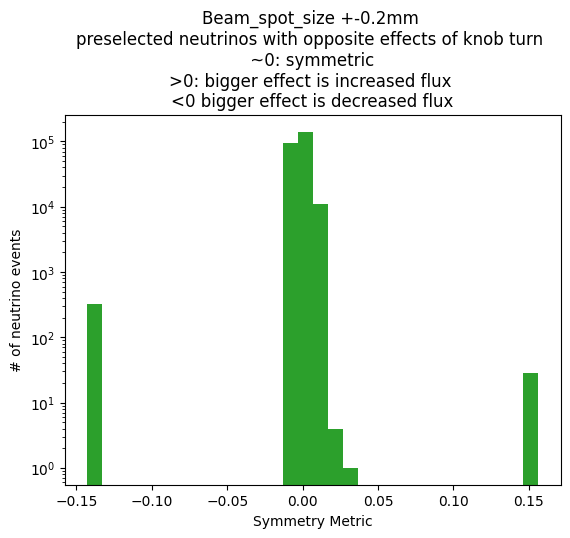

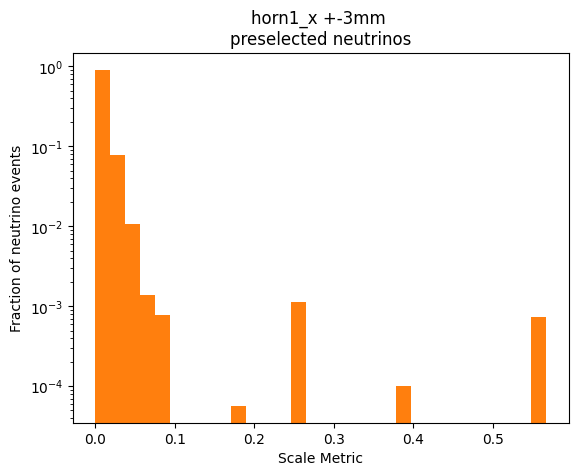

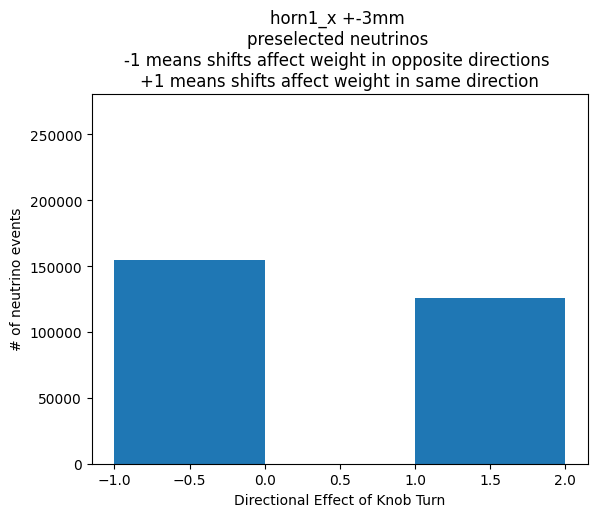

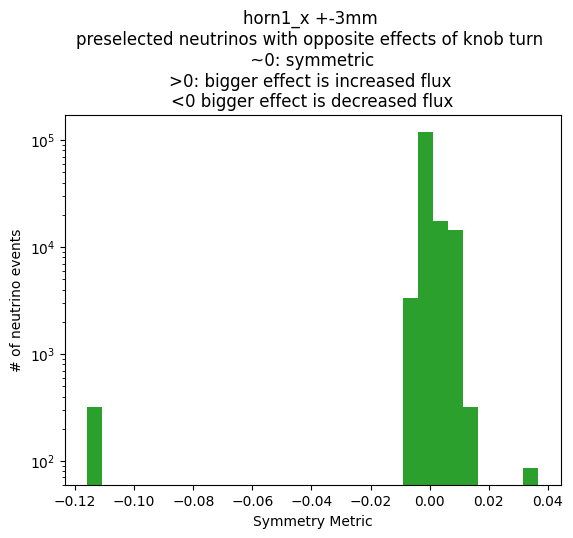

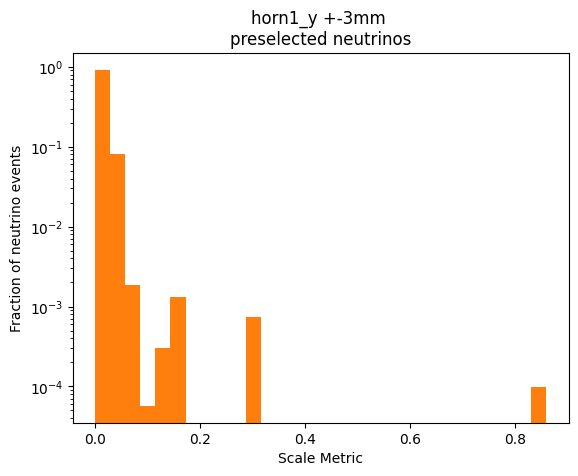

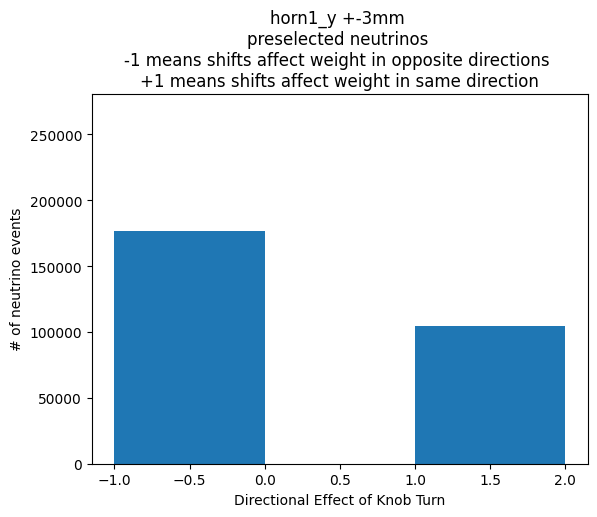

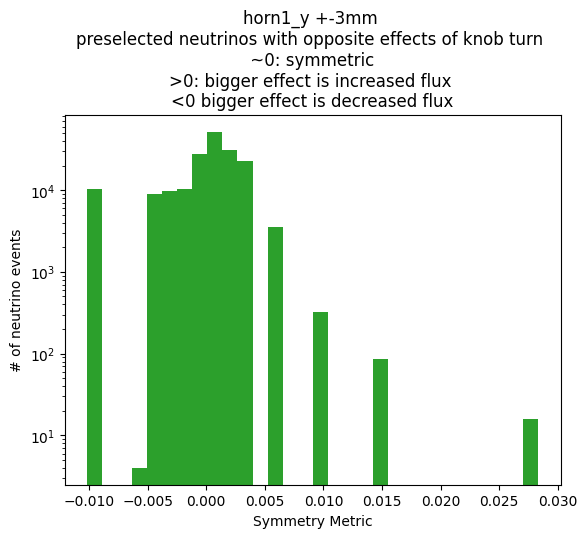

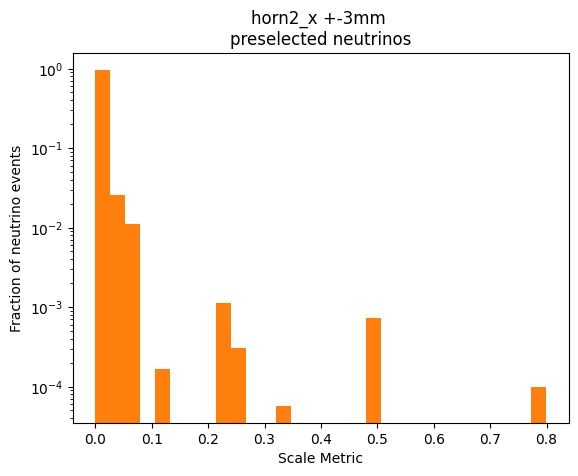

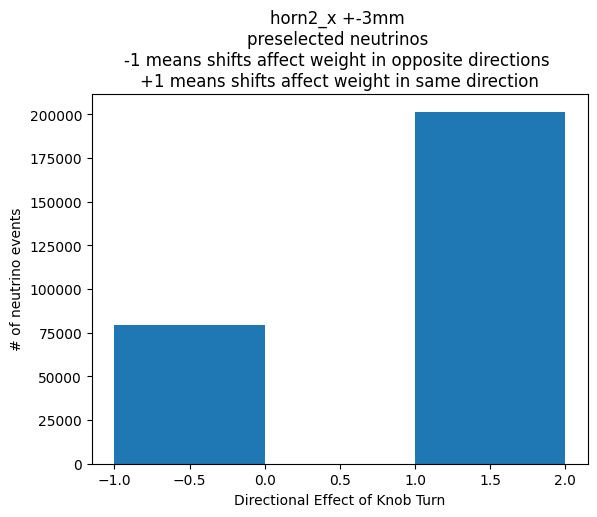

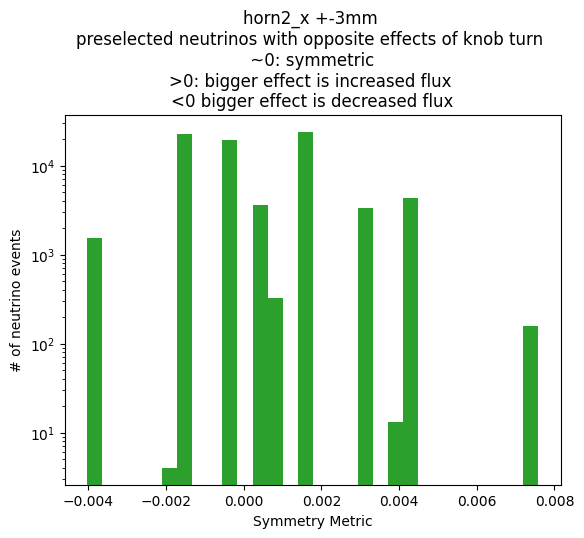

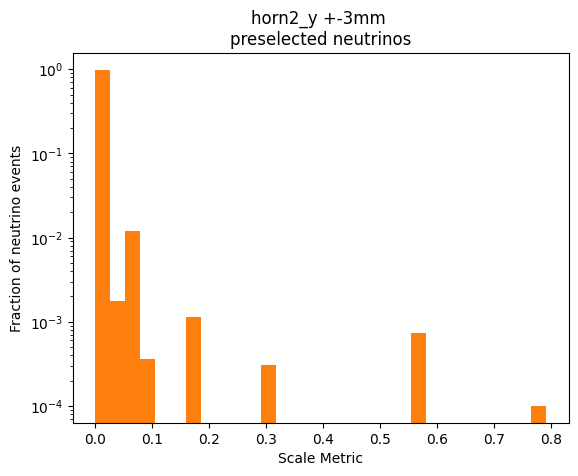

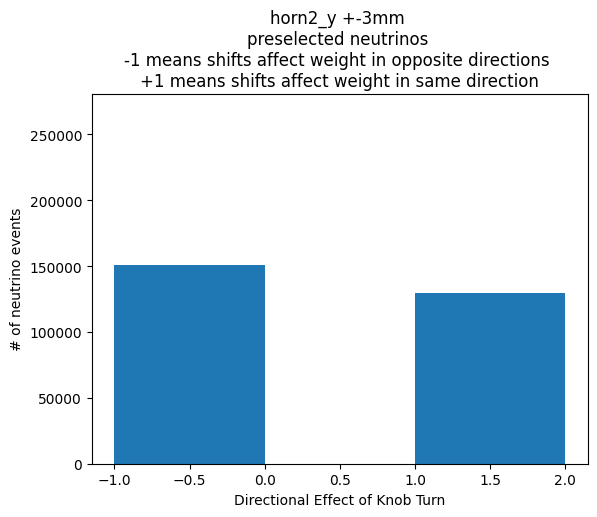

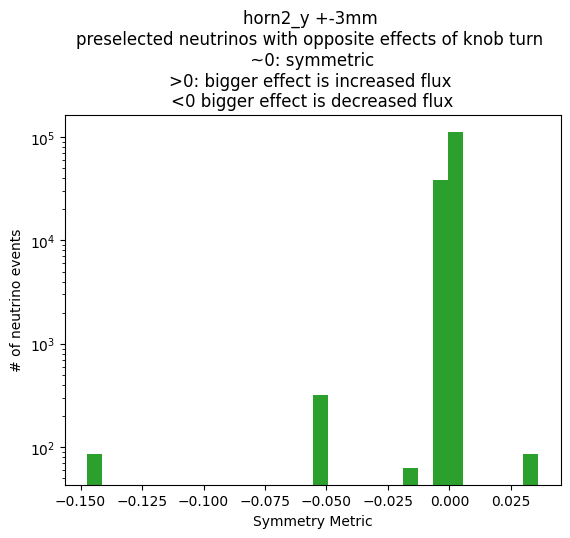

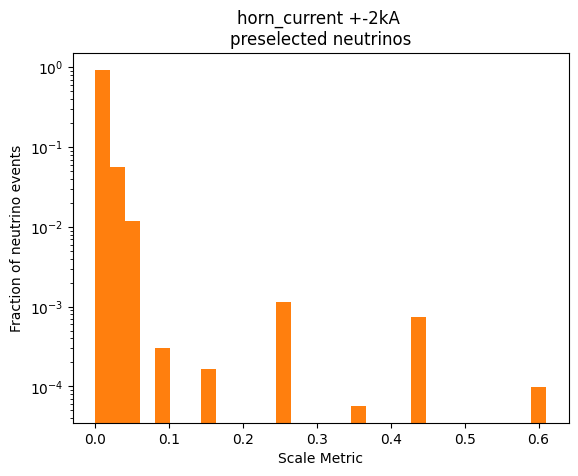

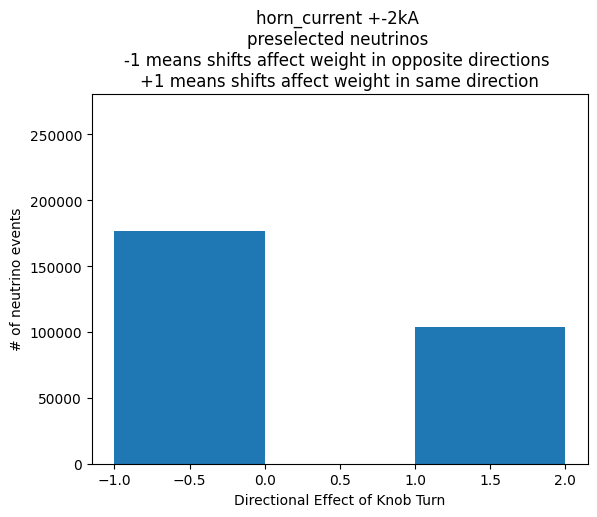

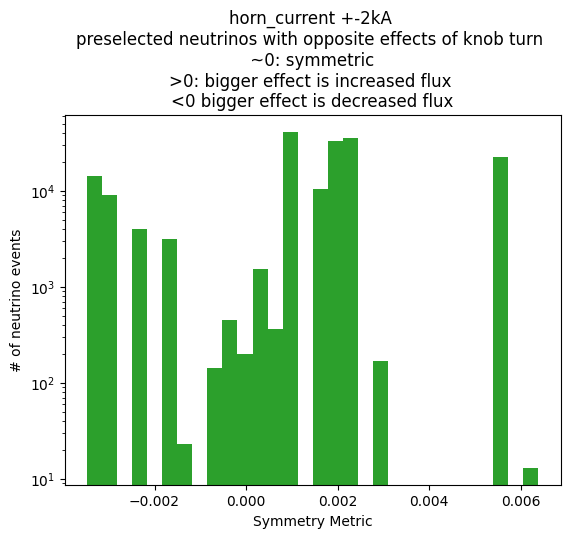

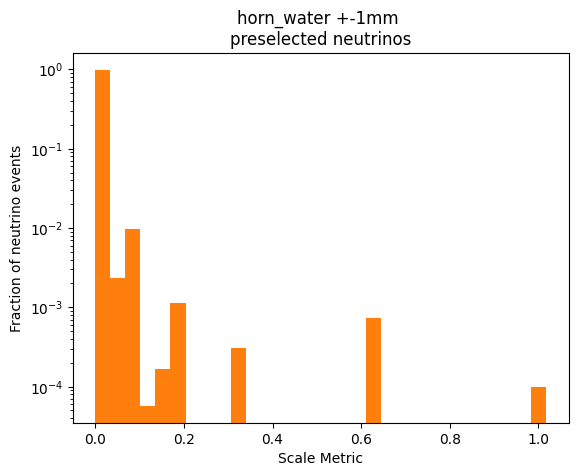

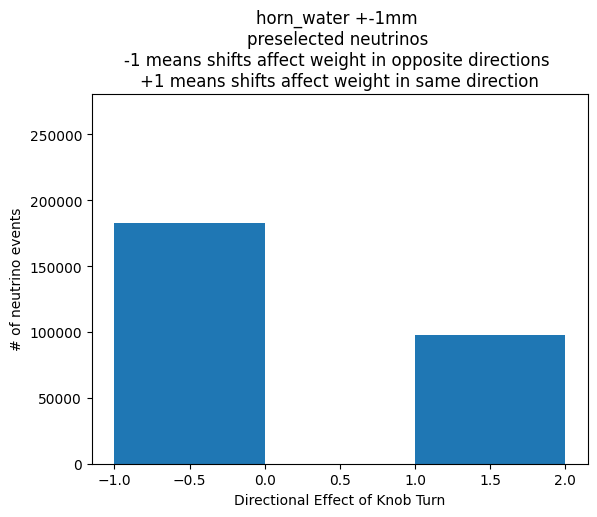

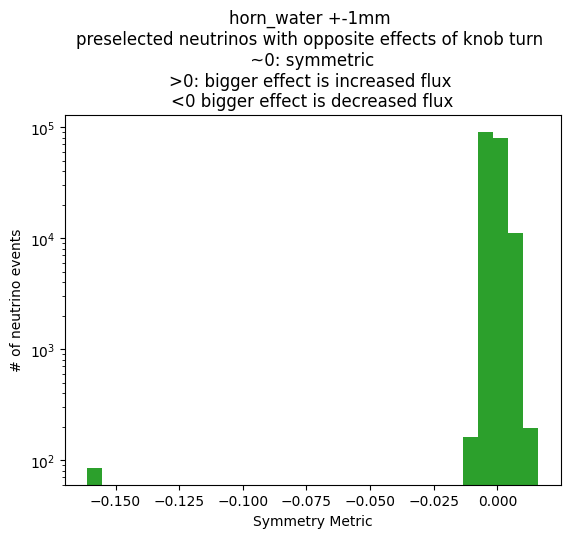

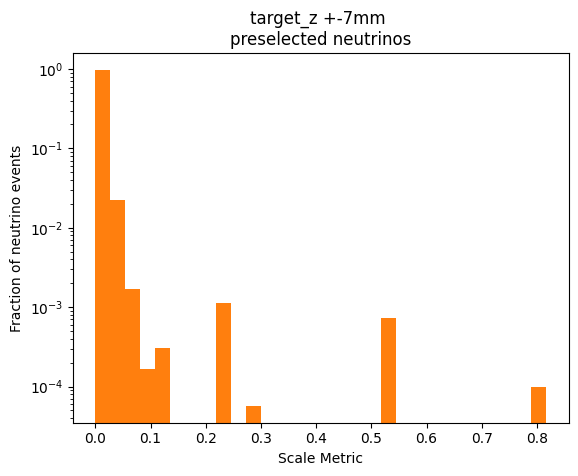

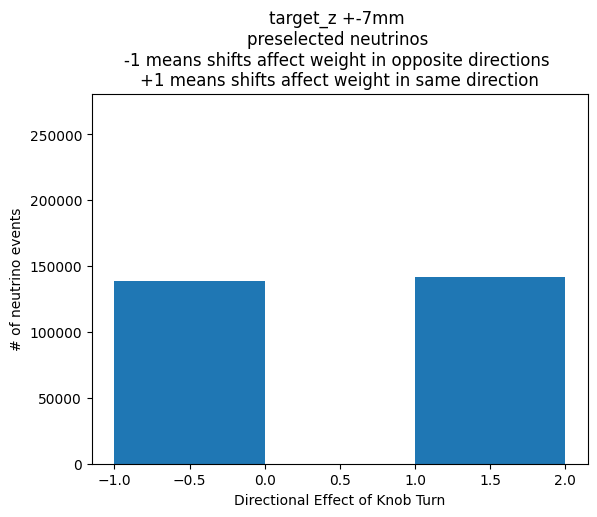

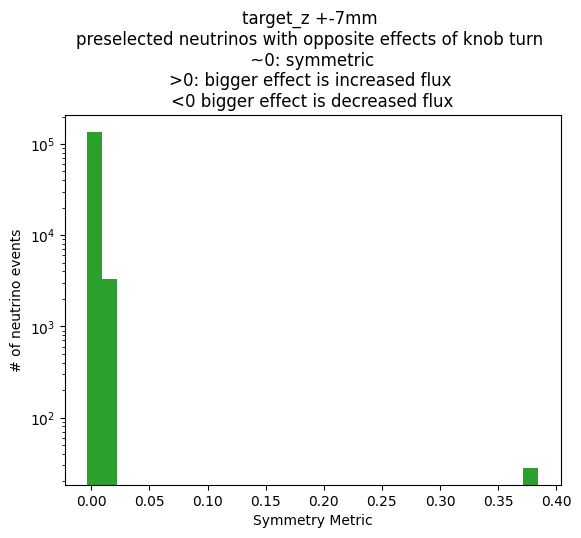

In [58]:
# Two bin hist: 
# value = -1 : +&- knob turns have change flux in opposite directions.
# value = +1 : +&- knob turns have change flux in same direction.
print(test.shape)
print(np.sign(-2))
scalebins=30
symmbins=30

# scale
plt.hist(test["Beam_shift_x_p1mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('Beam_shift_x +-1mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Beam_shift_x_p1mm",'mysign'], bins=3, range=(-1,2))
plt.title('Beam_shift_x +-1mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Beam_shift_x_p1mm",'symm_metric'][test["Beam_shift_x_p1mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('Beam_shift_x +-1mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()

# scale
plt.hist(test["Beam_shift_y_p1mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('Beam_shift_y +-1mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Beam_shift_y_p1mm",'mysign'], bins=3, range=(-1,2))
plt.title('Beam_shift_y +-1mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Beam_shift_y_p1mm",'symm_metric'][test["Beam_shift_y_p1mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('Beam_shift_y +-1mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()

# scale
plt.hist(test["Beam_spot_1_7mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('Beam_spot_size +-0.2mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Beam_spot_1_7mm",'mysign'], bins=3, range=(-1,2))
plt.title('Beam_spot_size +-0.2mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Beam_spot_1_7mm",'symm_metric'][test["Beam_spot_1_7mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('Beam_spot_size +-0.2mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()


# scale
plt.hist(test["Horn1_x_p3mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('horn1_x +-3mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Horn1_x_p3mm",'mysign'], bins=3, range=(-1,2))
plt.title('horn1_x +-3mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Horn1_x_p3mm",'symm_metric'][test["Horn1_x_p3mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('horn1_x +-3mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()


# scale
plt.hist(test["Horn1_y_p3mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('horn1_y +-3mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Horn1_y_p3mm",'mysign'], bins=3, range=(-1,2))
plt.title('horn1_y +-3mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Horn1_y_p3mm",'symm_metric'][test["Horn1_y_p3mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('horn1_y +-3mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()


# scale
plt.hist(test["Horn2_x_p3mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('horn2_x +-3mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Horn2_x_p3mm",'mysign'], bins=3, range=(-1,2))
plt.title('horn2_x +-3mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.show()
# symm
plt.hist(test["Horn2_x_p3mm",'symm_metric'][test["Horn2_x_p3mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('horn2_x +-3mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()

# scale
plt.hist(test["Horn2_y_p3mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('horn2_y +-3mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Horn2_y_p3mm",'mysign'], bins=3, range=(-1,2))
plt.title('horn2_y +-3mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Horn2_y_p3mm",'symm_metric'][test["Horn2_y_p3mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('horn2_y +-3mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()

# scale
plt.hist(test["Horn_p2kA",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('horn_current +-2kA \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Horn_p2kA",'mysign'], bins=3, range=(-1,2))
plt.title('horn_current +-2kA \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Horn_p2kA",'symm_metric'][test["Horn_p2kA",'mysign']<0], color='C2', bins=symmbins)
plt.title('horn_current +-2kA \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()


# scale
plt.hist(test["Horns_2mm_water",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('horn_water +-1mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Horns_2mm_water",'mysign'], bins=3, range=(-1,2))
plt.title('horn_water +-1mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Horns_2mm_water",'symm_metric'][test["Horns_2mm_water",'mysign']<0], color='C2', bins=symmbins)
plt.title('horn_water +-1mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()

# scale
plt.hist(test["Target_z_p7mm",'scale_metric'], weights=[1./test.shape[0]]*test.shape[0], color='C1', bins=scalebins)
plt.title('target_z +-7mm \npreselected neutrinos')
plt.ylabel('Fraction of neutrino events')
plt.xlabel('Scale Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()
# sign
plt.hist(test["Target_z_p7mm",'mysign'], bins=3, range=(-1,2))
plt.title('target_z +-7mm \npreselected neutrinos \n-1 means shifts affect weight in opposite directions \n+1 means shifts affect weight in same direction')
plt.ylabel('# of neutrino events')
plt.xlabel('Directional Effect of Knob Turn')
plt.ylim((0,test.shape[0]))
plt.show()
# symm
plt.hist(test["Target_z_p7mm",'symm_metric'][test["Target_z_p7mm",'mysign']<0], color='C2', bins=symmbins)
plt.title('target_z +-7mm \npreselected neutrinos with opposite effects of knob turn \n ~0: symmetric \n>0: bigger effect is increased flux \n<0 bigger effect is decreased flux')
plt.ylabel('# of neutrino events')
plt.xlabel('Symmetry Metric')
plt.yscale('log')
#plt.xscale('log')
plt.show()




### Now test numisyst again, now that I've symmetrized the focusing systematics

In [2]:
# run the contents of numisyst here since I can't import it from other directory.


In [5]:
symm_test = numisyst(mcdf.pdg, mcdf.E)

In [6]:
for c in symm_test.columns:
    print(c)

('ppfx', 'cv')
('Beam_shift_x', 'actual_ps1')
('Beam_shift_x', 'actual_ms1')
('Beam_shift_x', 'ps1')
('Beam_shift_x', 'ms1')
('Beam_shift_y', 'actual_ps1')
('Beam_shift_y', 'actual_ms1')
('Beam_shift_y', 'ps1')
('Beam_shift_y', 'ms1')
('Beam_spot', 'actual_ps1')
('Beam_spot', 'actual_ms1')
('Beam_spot', 'ps1')
('Beam_spot', 'ms1')
('Horn1_x', 'actual_ps1')
('Horn1_x', 'actual_ms1')
('Horn1_x', 'ps1')
('Horn1_x', 'ms1')
('Horn1_y', 'actual_ps1')
('Horn1_y', 'actual_ms1')
('Horn1_y', 'ps1')
('Horn1_y', 'ms1')
('Horn2_x', 'actual_ps1')
('Horn2_x', 'actual_ms1')
('Horn2_x', 'ps1')
('Horn2_x', 'ms1')
('Horn2_y', 'actual_ps1')
('Horn2_y', 'actual_ms1')
('Horn2_y', 'ps1')
('Horn2_y', 'ms1')
('Horn_current', 'actual_ps1')
('Horn_current', 'actual_ms1')
('Horn_current', 'ps1')
('Horn_current', 'ms1')
('Horn_water', 'actual_ps1')
('Horn_water', 'actual_ms1')
('Horn_water', 'ps1')
('Horn_water', 'ms1')
('Target_z', 'actual_ps1')
('Target_z', 'actual_ms1')
('Target_z', 'ps1')
('Target_z', 'ms1')
(

In [75]:
print(np.max(np.abs(1-symm_test.Horn1_x.ps1) - np.abs(1-symm_test.Horn1_x.ms1))) # basically zero, as expected

1.1102230246251565e-16


## (end of study)

## Now that I have some updated dataframes w/ the flux updates and extra CAF variables, look at some additional distributions.
Note: Once I adopt these for real, I will want to put my finalized dataframe samples into unc_samples.py and unc_MC_overhead scripts, and then remake these in other notebooks, like the event selection notebook. Since these dataframes are likely not finalized, do all of that here now instead (and don't mess up what works with my older dataframes in the other scripts).

In [34]:
# updated dataframe samples (stuff that would be in unc_samples.py):
updated_df_dir = '/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/'
higgs_files = [
    updated_df_dir + "ms300.df",
    updated_df_dir + "ms320.df",
    updated_df_dir + "ms350.df",
]
alp_nosup_files = [
    updated_df_dir + "ma300_faE6.df",
    updated_df_dir + "ma340_faE6.df",
    updated_df_dir + "ma350_faE6.df",
    updated_df_dir + "ma400_faE6.df",
    updated_df_dir + "ma450_faE6.df",
    updated_df_dir + "ma500_faE6.df",
    updated_df_dir + "ma540_faE6.df",
    updated_df_dir + "ma600_faE6.df",
    updated_df_dir + "ma650_faE6.df",
    updated_df_dir + "ma700_faE6.df"
]
#nu_file = updated_df_dir + 
cohlike_nu_file = updated_df_dir + "more_Cohlike.df"





In [35]:
print(GOAL_POT)

2.41e+20


In [55]:
%%time

# stuff that would be in unc_MC_overhead.py:

# HPS

higgs_mcdfs = [pd.read_hdf(f, key="mch") for f in higgs_files]
higgs_mcnudfs = [pd.read_hdf(f, key="mcnu") for f in higgs_files]
for i, mch in enumerate(higgs_mcdfs):
    Sdir = mch.exit-mch.enter
    Sdir_mag = np.linalg.norm(Sdir, axis=1)
    Sdir = Sdir/Sdir_mag[:, None]
    mch["POIdir","x"] = Sdir.x # "POI" is for "particle of interest" (scalar, alp, or nu)
    mch["POIdir","y"] = Sdir.y
    mch["POIdir","z"] = Sdir.z
    higgs_mcnudfs[i]["POIdir_x"] = Sdir.x
    higgs_mcnudfs[i]["POIdir_y"] = Sdir.y
    higgs_mcnudfs[i]["POIdir_z"] = Sdir.z
#for c in higgs_mcdfs[0].columns: print(c)
higgs_masses = [int(round(df.iloc[(0)].M*1000.)) for df in higgs_mcdfs]
higgs_thetas = [float(df.iloc[(0)].C1) for df in higgs_mcdfs]
higgs_mass_labels = []
higgs_th_labels = []
higgs_labels = []
for i in range(len(higgs_files)):
    higgs_mass_labels.append("$M_S$ = %a" % higgs_masses[i])
    higgs_th_labels.append("$\\theta_S$ = %a" % higgs_thetas[i])
    higgs_labels.append(higgs_mass_labels[i] + ", " + higgs_th_labels[i])
    
# ALP Files (ALPs WITHOUT MASS SUPPRESSION)

alp_nosup_mcdfs = [pd.read_hdf(f, key="mch") for f in alp_nosup_files]
alp_nosup_mcnudfs = [pd.read_hdf(f, key="mcnu") for f in alp_nosup_files]
for i, mch in enumerate(alp_nosup_mcdfs):
    ALPdir = mch.exit-mch.enter
    ALPdir_mag = np.linalg.norm(ALPdir, axis=1)
    ALPdir = ALPdir/ALPdir_mag[:, None]
    mch["POIdir","x"] = ALPdir.x
    mch["POIdir","y"] = ALPdir.y
    mch["POIdir","z"] = ALPdir.z
    alp_nosup_mcnudfs[i]["POIdir_x"] = ALPdir.x
    alp_nosup_mcnudfs[i]["POIdir_y"] = ALPdir.y
    alp_nosup_mcnudfs[i]["POIdir_z"] = ALPdir.z

alp_nosup_masses = [int(round(df.iloc[(0)].M*1000.)) for df in alp_nosup_mcdfs]
alp_nosup_fa = [float(df.iloc[(0)].C1) for df in alp_nosup_mcdfs] #play with this one!
alp_nosup_cAl = [float(df.iloc[(0)].C2) for df in alp_nosup_mcdfs]
#print(alp_nosup_masses, alp_nosup_fa, alp_nosup_cAl, sep='\n')
alp_nosup_mass_labels = []
alp_nosup_fa_labels = []
alp_nosup_cAl_labels = []
alp_nosup_labels = []
for i in range(len(alp_nosup_files)):
    alp_nosup_mass_labels.append("$M_{ALP}$ = %a" % alp_nosup_masses[i])
    alp_nosup_fa_labels.append("$fa$ = %a" % "{:.1e}".format(alp_nosup_fa[i]))
    if len(str(alp_nosup_fa[i]))-str(alp_nosup_fa[i]).count('0') > 2:
        print('WARNING: Your fa labels might be misleading. You should double check them, and fix if needed.')
    alp_nosup_cAl_labels.append("$c$ = %a" % alp_nosup_cAl[i])
    alp_nosup_labels.append(alp_nosup_mass_labels[i] + ", " + alp_nosup_cAl_labels[i] + ", " + alp_nosup_fa_labels[i])

# NEUTRINOS

nu_files = [cohlike_nu_file]#[nu_file, cohlike_nu_file, cohlike_nu_file_extra_2501, 
            #cohlike_nu_file_extra_2502_12, cohlike_nu_file_extra_2502_34, cohlike_nu_file_extra_2502_5, 
            #cohlike_nu_file_extra_2502_6789]
nu_labels = ["Coh-like $\\nu$"]#["$\\nu$", "Coh-like $\\nu$", "Coh-like $\\nu$ (ad'l 2501)", 
             #"Coh-like $\\nu$ (ad'l 2502_12)", "Coh-like $\\nu$ (ad'l 2502_34)", "Coh-like $\\nu$ (ad'l 2502_5)",
             #"Coh-like $\\nu$ (ad'l 2502_6789)"]#*len(nu_files)
nu_masses = [-1]*len(nu_files)
nu_mcnudfs = [pd.read_hdf(f, key="mcnu") for f in nu_files]
for df in nu_mcnudfs:
    nudir = df.momentum
    nudir_mag = np.linalg.norm(nudir, axis=1)
    nudir = nudir/nudir_mag[:, None]
    df["POIdir_x"] = nudir.x
    df["POIdir_y"] = nudir.y
    df["POIdir_z"] = nudir.z

# PUT IT ALL TOGETHER:

labels = higgs_labels + alp_nosup_labels + nu_labels
masses = higgs_masses + alp_nosup_masses + nu_masses # MeV
df_files = higgs_files + alp_nosup_files + nu_files
mcnudfs = higgs_mcnudfs + alp_nosup_mcnudfs + nu_mcnudfs

## IF YOU DO NOT CARE ABOUT CV WEIGHTS:

#evtdfs = [pd.read_hdf(f, key="evt") for f in df_files]

# IF YOU DO CARE ABOUT CV WEIGHTS:

def add_cv_weights(file, mccut=None,
                   mc=True, mc_incoh=False, mccoh=False,
                   bsm=False, hps=False, alp=False,
                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                  ):
    evt = mc_dataset(file, "evt", mcnukey="mcnuwgt", syst_weights=False)#, mccut=mccut)
    evt_df = evt.df
    if mccut is not None:
        print('recognized mccut')
        print('shape of evt_df before applying mccut: ', evt_df.shape)
        evt_df = evt_df[mccut(evt_df)]
        print('shape of evt_df after applying mccut: ', evt_df.shape)
    evt_df["mc"] = mc
    evt_df["mc_incoh"] = mc_incoh
    evt_df["mccoh"] = mccoh
    evt_df["bsm"] = bsm
    evt_df["hps"] = hps
    evt_df["alp"] = alp
    evt_df["onbeam"] = evt_df["offbeam"] = evt_df["Run1"] = evt_df["Run2"] = False
    evt_df['livetime'] = evt.livetime
    evt_df['POT'] = evt.POT
    evt_df['scale'] = GOAL_POT / evt.POT
    #print('livetime: ', evt.livetime)
    #print('POT: ', evt.POT)
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df)
    
    return evt_df

higgs_evtdfs = [add_cv_weights(file, bsm=True, hps=True) for file in higgs_files]
alp_evtdfs = [add_cv_weights(file, bsm=True, alp=True) for file in alp_nosup_files]
nu_evtdfs = [add_cv_weights(file, mccut=is_coh_like_JD, mccoh=True) for file in nu_files]
evtdfs = higgs_evtdfs + alp_evtdfs + nu_evtdfs
evtdf = jamie_sample_concat(evtdfs)



/tmp/ipykernel_612512/797777115.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  cv = math.prod([mcdf[w] for w in weights.cv])
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/tmp/ipykernel_612512/797777115.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  return multicol_merge(df, wgtdf, how="left", left_on=wgtdf.index.names[:2] + [tmatch_col], right_index=True).fillna(na_set)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villia

Generating Coh-weights!
Generated


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:619: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:619: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

Generating Coh-weights!
Generated


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:619: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=s

...

Generating Coh-weights!
Generated
recognized mccut
shape of evt_df before applying mccut:  (22148, 287)


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
<timed exec>:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<timed exec>:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

shape of evt_df after applying mccut:  (16530, 287)


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:619: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:619: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

CPU times: user 2min 37s, sys: 2min 27s, total: 5min 5s
Wall time: 1min 24s


In [56]:
for c in evtdf.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [58]:
print(max(abs(evtdf.wgt.cv.tot - (evtdf.wgt.cv.ppfx*evtdf.wgt.cv.flux_other_than_ppfx*evtdf.wgt.cv.coh))))

0.0


In [21]:
print(len(higgs_files))
print(len(higgs_evtdfs))


print(len(evtdfs))
print(evtdf.shape)
evtdf.sample



3
3
14
(289163, 314)


<bound method NDFrame.sample of                                                  slc                         \
                                     is_clear_cosmic      vertex              
                                                               x          y   
                                                                              
                                                                              
                                                                              
sample __ntuple entry rec.slc..index                                          
0      3        10    17                           0  180.888535  96.911568   
                15    22                           0  268.073883  16.779053   
                17    1                            0 -121.479462 -32.154297   
                20    14                           0  234.445953 -94.641418   
                23    1                            0 -118.024918  46.773560   
..                  

In [50]:
# Copied from unc_request_NearSB.ipynb
    
# detailed_nu option will further classify the MC samples by types of neutrino interactions.

def make_categories(df, detailed_bsm = False, detailed_nu = 'int_type'):
# Use this function to categorize the MC samples (signal and bg) that are used in designing the event selection.
# options for 'detailed_nu' are: 'int_type', 'final_state', 'none'. Use 'int_type!' On 4/8/25, I verfied that int_type categories are same as what's used unc_funcs (make_categories func for MC studies)
    
    cat_colors = soladero_lime
    
    # DATA
    
    #onbeam = (df.loc[[2]])
    onbeam = (df.onbeam == True)
    onbeam.name = 'Onbeam Data'
    onbeam.color = 'black' #"#E6378F"
    
    #offbeam = (df.loc[[3]])
    offbeam = (df.offbeam == True)
    offbeam.name = 'Offbeam Data'
    offbeam.color = "#EC1C0E"

    
    # COSMICS
    #is_cosmic = (df.slc.tmatch.idx < 0)
    is_cosmic = (df.slc.tmatch.idx < 0) #& (df.bsm==False) ) # Note 5/2/25: this is different from other instances of make_categories function I have, and it's because since I am POT-normalizing to get background estimates, I shouldn't include model-dependent cosmics. (They are very few anyways.) 
    is_cosmic.name = "Cosmic"
    is_cosmic.color = soladero_lime[6] #"C3"
    
    # SIGNAL
    
    if detailed_bsm:
        
        is_higgs = ( (df.slc.tmatch.idx >= 0) & (df.hps) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) )# Only consider muon channel, exclude any Higgs that decayed to pions.
        higgs_benchmarks = []
        for s, sample in enumerate(df[is_higgs].index.get_level_values('sample').unique()):
            bm = (is_higgs) & (df.index.get_level_values('sample') == sample)
            bm.name = higgs_labels[s]
            bm.color = blues[s]
            higgs_benchmarks.append(bm)
        #higgs_benchmark_names = df[is_higgs]["sample"].unique() # Made this change June 3 to avoid bug when applying cuts, where you eliminate all of one category so your results dataframe shape gets messed up. Hopefully this doesn't cause other problems.
        #print(higgs_benchmark_names)
        #for l in range(len(higgs_benchmark_names)):
        #    bm = is_higgs & (df["sample"] == higgs_benchmark_names[l])
        #    bm.name = higgs_benchmark_names[l]
        #    bm.color = blues[l]
        #    higgs_benchmarks.append( bm )    
        
        is_alp = (df.slc.tmatch.idx >= 0) & df.alp & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0)
        alp_benchmarks = []
        for s, sample in enumerate(df[is_alp].index.get_level_values('sample').unique()):
            bm = (is_alp) & (df.index.get_level_values('sample') == sample)
            bm.name = alp_nosup_labels[s]
            bm.color = greens[s]
            alp_benchmarks.append(bm)
        #is_alp.name = "ALP"
        #alp_benchmarks = []
        #alp_benchmark_names = df[is_alp]["sample"].unique()
        #for l in range(len(alp_benchmark_names)):
        #    bm = is_alp & (df["sample"] == alp_benchmark_names[l])
        #    bm.name = alp_benchmark_names[l]# + " (no sup.)"
        #    bm.color = greens[l]
        #    alp_benchmarks.append( bm )
        
        bsm_cats = higgs_benchmarks + alp_benchmarks
            
    else:
        is_bsm = (df.slc.tmatch.idx >= 0) & (df.slc.truth.npi == 0) & (df.slc.truth.npi0 == 0) & (df.hps | df.alp ) # ( df.higgs | df.hps | df.alp_withsup | df.alp_nosup )
        is_bsm.name = "BSM"
        is_bsm.color = "#191970" #, "#00FF7F" #"#000000"
        bsm_cats = [is_bsm]
    
    # NEUTRINOS
    
    is_nu = (df.slc.tmatch.idx >= 0) & ( df.mc_incoh | df.mccoh )
    
    if detailed_nu == 'int_type':
        
        nu_NC = (is_nu & df.mc & (df.slc.truth.iscc == 0))
        nu_NC.name = "$\\nu$ NC"
        nu_NC.color = cat_colors[0] #"#caa834" #"#EAC387"
        
        numu_CC_QE_MEC = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & ((df.slc.truth.genie_mode == 0) | (df.slc.truth.genie_mode == 10)) # CC QE+MEC
        numu_CC_QE_MEC.name = "$\\nu_\\mu$ CC QE+MEC"
        numu_CC_QE_MEC.color = cat_colors[1] 
        
        numu_CC_RES = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 1) # CC RES
        numu_CC_RES.name = "$\\nu_\\mu$ CC RES"
        numu_CC_RES.color = cat_colors[2]
        
        numu_CC_DIS = is_nu & df. mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 2) # CC DIS
        numu_CC_DIS.name = "$\\nu_\\mu$ CC DIS"
        numu_CC_DIS.color = cat_colors[3] 
        
        numu_CC_COH = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 3) # CC COH
        numu_CC_COH.name = "$\\nu_\\mu$ CC COH"
        numu_CC_COH.color = cat_colors[4]
        
        #
        nu_other = is_nu & df.mc & ~nu_NC & ~numu_CC_QE_MEC & ~numu_CC_RES & ~numu_CC_DIS & ~numu_CC_COH
        nu_other.name = "$\\nu$ Other"
        nu_other.color = cat_colors[5]  
        
        nu_cats = [nu_NC] + [numu_CC_QE_MEC] + [numu_CC_RES] + [numu_CC_DIS] + [numu_CC_COH] + [nu_other]
    
    if detailed_nu == 'final_state':
        numu_cc_coh = df.mc & (df.slc.truth.genie_mode == 3) & (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool'))
        numu_cc_coh.name = '$\\nu_\\mu$ CC COH'
        numu_cc_coh.color = '#FADD28' #oranges[0]
        
        numu_cc_npizp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) &
                         (df.slc.truth.max_proton_ke < 0.02) )
        numu_cc_npizp.name = "$\\nu_\\mu$ CC n$\\pi$0p"
        numu_cc_npizp.color = oranges[1]
        
        numu_cc_npinp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) & 
                         (df.slc.truth.max_proton_ke >= 0.02))
        numu_cc_npinp.name = '$\\nu_\\mu$ CC n$\\pi$np'
        numu_cc_npinp.color = oranges[2]
        
        numu_cc_other = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & 
                         (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool')) & 
                         ( (df.slc.truth.npi<1) | (df.slc.truth.npi0!=0) )
                        )
        numu_cc_other.name = '$\\nu_\\mu$ CC Other'
        numu_cc_other.color = oranges[3]
        
        not_numu_cc = (df.mc & ( (np.abs(df.slc.truth.pdg) != 14) | ~df.slc.truth.iscc.astype('bool') ))
        not_numu_cc.name = 'not $\\nu_\\mu$ CC'
        not_numu_cc.color = oranges[4]
        
        nu_cats = [numu_cc_coh] + [numu_cc_npizp] + [numu_cc_npinp] + [numu_cc_other] + [not_numu_cc]
    
    elif detailed_nu == 'none':
        
        nu_all = is_nu
        nu_all.name = r'$\nu$'
        nu_all.color = 'C2' 
        
        nu_cats = [nu_all] 
    
    # PUT THEM ALL TOGETHER
    
    for m in bsm_cats:
        m.mc_signal = True
        m.mc_bg = False
    for m in nu_cats:
        m.mc_signal = False
        m.mc_bg = True
    is_cosmic.mc_signal = False
    is_cosmic.mc_bg = True
    
    categories = bsm_cats + nu_cats + [is_cosmic]
    return categories

def filter_out_cosmics(df):
    is_cosmic = df.slc.tmatch.idx < 0
    return ~is_cosmic




In [51]:
categories = make_categories(evtdf, detailed_nu = 'int_type', detailed_bsm=True)
for c in categories:
    print(c.name)
    print(evtdf[c].shape)

$M_S$ = 300, $\theta_S$ = 3e-05
(2272, 315)
$M_S$ = 320, $\theta_S$ = 1e-05
(31, 315)
$M_S$ = 350, $\theta_S$ = 1e-05
(106, 315)
$M_{ALP}$ = 300, $c$ = 0.01, $fa$ = '1.0e+06'
(14563, 315)
$M_{ALP}$ = 340, $c$ = 0.01, $fa$ = '1.0e+06'
(17072, 315)
$M_{ALP}$ = 350, $c$ = 0.01, $fa$ = '1.0e+06'
(17815, 315)
$M_{ALP}$ = 400, $c$ = 0.01, $fa$ = '1.0e+06'
(19837, 315)
$M_{ALP}$ = 450, $c$ = 0.01, $fa$ = '1.0e+06'
(22268, 315)
$M_{ALP}$ = 500, $c$ = 0.01, $fa$ = '1.0e+06'
(24273, 315)
$M_{ALP}$ = 540, $c$ = 0.01, $fa$ = '1.0e+06'
(25907, 315)
$M_{ALP}$ = 600, $c$ = 0.01, $fa$ = '1.0e+06'
(25050, 315)
$M_{ALP}$ = 650, $c$ = 0.01, $fa$ = '1.0e+06'
(24901, 315)
$M_{ALP}$ = 700, $c$ = 0.01, $fa$ = '1.0e+06'
(24660, 315)
$\nu$ NC
(152, 315)
$\nu_\mu$ CC QE+MEC
(249, 315)
$\nu_\mu$ CC RES
(3951, 315)
$\nu_\mu$ CC DIS
(4235, 315)
$\nu_\mu$ CC COH
(349, 315)
$\nu$ Other
(21, 315)
Cosmic
(61408, 315)


In [40]:
for c in evtdf.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('

In [45]:
print(evtdf.scale.shape)
print(evtdf.wgt.cv.shape)
evtdf.wgt

(289163,)
(289163, 2)


cv                      coh
                                               other_than_ppfx       cv
                                                                       
                                                                       
                                                                       
sample __ntuple entry rec.slc..index                                   
0      3        10    17              0.607859        0.624012  1.00000
                15    22              1.000000        1.000000  1.00000
                17    1               0.607859        0.624012  1.00000
                20    14              0.608327        0.666586  1.00000
                23    1               0.660854        0.707038  1.00000
...                                        ...             ...      ...
13     800      25    0               1.769406        0.621290  3.12925
                29    2               0.565441        0.621290  1.00000
                35    0               0.753353        0.785181  1.00000
                36    16              0.551590        0.537836  1.00000
                38    1               0.364431        0.344891  1.00000

[289163 rows x 3 columns]

In [52]:
# Plotting function common to all variables

def makeplot(df, var, myrange, xlabel = 'x axis',
             bins = 25, detailed_bsm=False, detailed_nu='none', hps_final_state=False,
             plotname='noname', density=True, logy=False, vline=[], title='', 
             categories='int_type',
             apply_cv_weights = False, 
             do_stat_err = False
            ):
    fig = plt.figure()
    ax = plt.subplot(111)
    scale = df.scale.copy()
    #var[np.isnan(var) | (var < 0)] = -10
    var[np.isnan(var)] = -10
    if categories == 'int_type':
        categories = make_categories(df, detailed_bsm = detailed_bsm,
                                     detailed_nu = detailed_nu)
    if categories == 'vtx':
        categories = make_vtxcategories(df)
    yrange = [0,0]
    for c in categories:
        # weights = [df[cat].scale*df[cat].wgt.cv for cat in categories[:-2]]
        if apply_cv_weights:
            hist = plt.hist(var[c], weights=df[c].scale*df[c]['wgt', 'cv', '', '', '', ''], bins=bins, label=c.name, color=c.color,
                                 histtype="step", linewidth=2, range=myrange, density=density)
        else:
            hist = plt.hist(var[c], weights=df[c].scale, bins=bins, label=c.name, 
                                  histtype="step", linewidth=2, range=myrange, density=density, color=c.color)
        if np.max(hist[0]) > yrange[1]: 
            yrange[1] = np.max(hist[0])*1.4
        # Get the statistical error bars for the above hists:
        if do_stat_err:
            if apply_cv_weights | density | logy: 
                print('Function not currently equipped to get statistical errors given other plot settings.')
                return 'Tough luck.'
            unq = np.unique(np.array(df[c].scale))
            arg_of_root = 0 # initialize
            temp = 0 # placeholder
            for w in unq:
                temp = plt.hist(var[c][df[c].scale==w],
                                bins=bins, alpha=0, density=False, range=myrange)
                arg_of_root = arg_of_root + (w**2)*temp[0]
            stat_err = np.sqrt( arg_of_root )
            plt.errorbar( 0.5*(temp[1][1:] + temp[1][:-1]),
                         hist[0],
                         marker = '.',
                         yerr = stat_err, 
                         color = c.color,
                         ls = 'none',
                         elinewidth=2
                        )
            if 'nu' in c.name:
                print('BIN VALUE: ', hist[0])
                print('STAT ERROR: ', stat_err)
        
    if density:
        plt.ylabel("Area Normalized")
    else:
        plt.ylabel("Events / %s" % POTSTR)
    plt.xlabel(xlabel)
    if logy:
        plt.yscale("log")
    if len(vline)==2:
        plt.axvline([vline[0]], color="r", linewidth=2) #, linestyle=":"
        plt.axvline([vline[1]], color="r", linewidth=2)
    else:
        for v in vline:
            plt.axvline([v], linestyle=":", color="r", linewidth=2) # , color="r"
    plt.title(title)
    plt.tight_layout()
    plt.xlim(myrange)
    if do_stat_err:
        yrange = (0,3)
        plt.ylim(yrange) # idk why it gets messed up without this, but it does.
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #ax.legend(loc = 'center left', bbox_to_anchor=(1, 0.5))
    if detailed_bsm:
        plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.075), ncol=2, fontsize='xx-small')
    else:
        plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.1), ncol=3, fontsize='x-small')
    if saveplots: plt.savefig(plotdir + 'MCdist_' + plotname + ".png", format='png', bbox_inches='tight')
    plt.show()
    

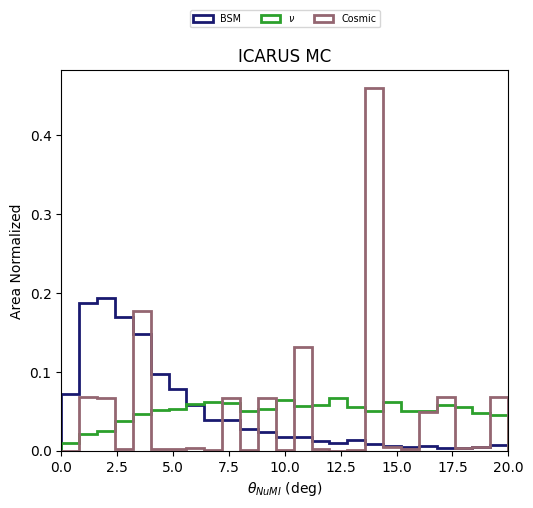

In [62]:
# THETA_NUMI - wgt by length (Use this one in analysis!)
myRange = (0,20.)
makeplot(evtdf, evtdf.Snumi_angle_wgtByLen*180./math.pi,
         myRange, 
         xlabel = "$\\theta_{NuMI}$ (deg)", # Wgt by Trk Len 
         bins = 25,
         detailed_bsm=False, #True,
         detailed_nu='none', # int_type, none
         plotname='theta_NuMI_wgtByTrkLen',
         density=True,
         logy=False,
         title='ICARUS MC', # all preselected events
         categories='int_type',
         apply_cv_weights = True
        )

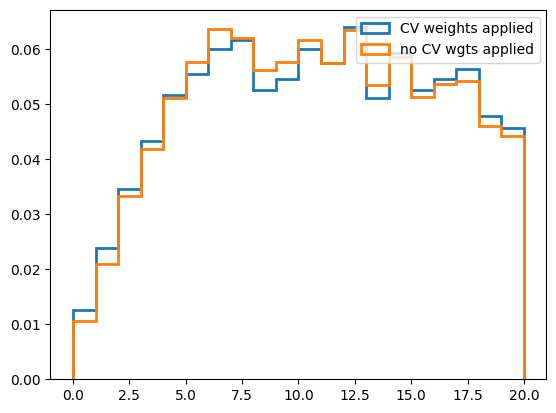

In [58]:
bins=20
myrange = (0,20.)
myDensity=True
plt.hist(evtdf.Snumi_angle_wgtByLen*180./math.pi, weights=evtdf.scale*evtdf['wgt', 'cv', '', '', '', ''], bins=bins,
         histtype="step", linewidth=2, range=myrange, density=myDensity, label='CV weights applied')
plt.hist(evtdf.Snumi_angle_wgtByLen*180./math.pi, weights=evtdf.scale, bins=bins,
         histtype="step", linewidth=2, range=myrange, density=myDensity, label='no CV wgts applied')
plt.legend()
plt.show()

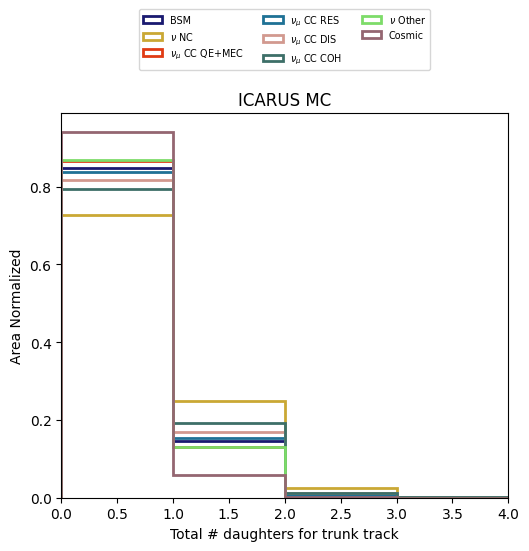

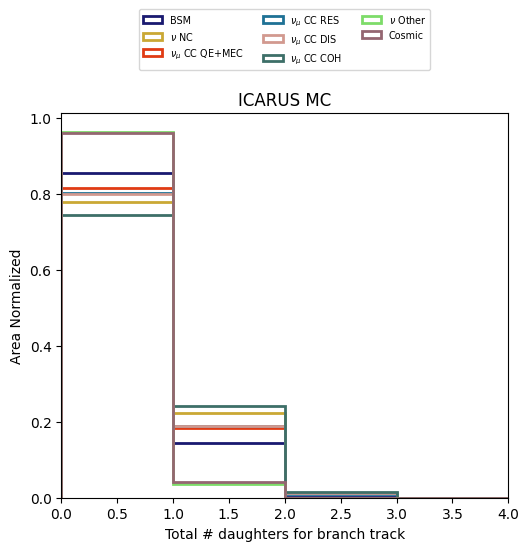

In [71]:
# NDAUGHTERS
myRange = (0,4)

# trunks
makeplot(evtdf, evtdf.trunk.ndaughters ,
         myRange, 
         xlabel = "Total # daughters for trunk track", # Wgt by Trk Len 
         bins = 4,
         detailed_bsm=False, #True,
         detailed_nu='int_type', # int_type, none
         plotname='trunk_ndaughters',
         density=True,
         logy=False,
         title='ICARUS MC', # all preselected events
         categories='int_type',
         apply_cv_weights = True
        )

# branches
makeplot(evtdf, evtdf.branch.ndaughters ,
         myRange, 
         xlabel = "Total # daughters for branch track", # Wgt by Trk Len 
         bins = 4,
         detailed_bsm=False, #True,
         detailed_nu='int_type', # int_type, none
         plotname='branch_ndaughters',
         density=True,
         logy=False,
         title='ICARUS MC', # all preselected events
         categories='int_type',
         apply_cv_weights = True
        )

In [91]:
# muon and pion masks

trunk_pion_mask = (np.abs(evtdf.trunk.trk.truth.p.pdg) == 211) 
branch_pion_mask = (np.abs(evtdf.branch.trk.truth.p.pdg) == 211) 
pion_weights = np.concatenate((np.array(evtdf[trunk_pion_mask]['wgt', 'cv', '', '', '', '']), 
                               np.array(evtdf[branch_pion_mask]['wgt', 'cv', '', '', '', ''])))

trunk_muon_mask = (np.abs(evtdf.trunk.trk.truth.p.pdg) == 13) 
branch_muon_mask = (np.abs(evtdf.branch.trk.truth.p.pdg) == 13)
muon_weights = np.concatenate((np.array(evtdf[trunk_muon_mask]['wgt', 'cv', '', '', '', '']), 
                               np.array(evtdf[branch_muon_mask]['wgt', 'cv', '', '', '', ''])))

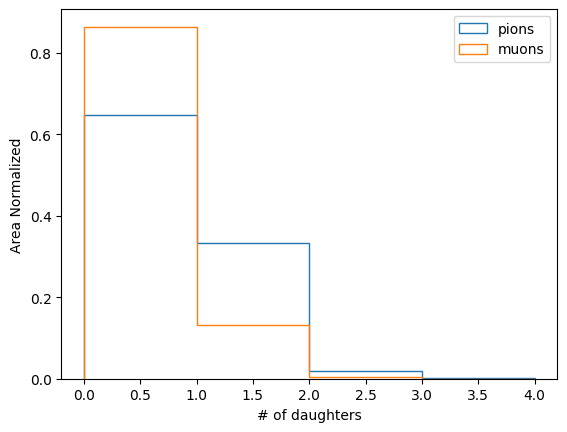

In [93]:
pion_ndaughters = np.concatenate((np.array(evtdf[trunk_pion_mask].trunk.ndaughters), 
                                  np.array(evtdf[branch_pion_mask].branch.ndaughters)))

muon_ndaughters = np.concatenate((np.array(evtdf[trunk_muon_mask].trunk.ndaughters), 
                                  np.array(evtdf[branch_muon_mask].branch.ndaughters)))

bins=4
myRange=(0,4)

plt.hist(pion_ndaughters, weights=pion_weights, bins=bins, range=myRange, label='pions', histtype='step', density=True)
plt.hist(muon_ndaughters, weights=muon_weights, bins=bins, range=myRange, label='muons', histtype='step', density=True)
plt.legend()
plt.ylabel('Area Normalized')
plt.xlabel('# of daughters')
plt.show()

# I want to know what the daughters get reconstructed as.


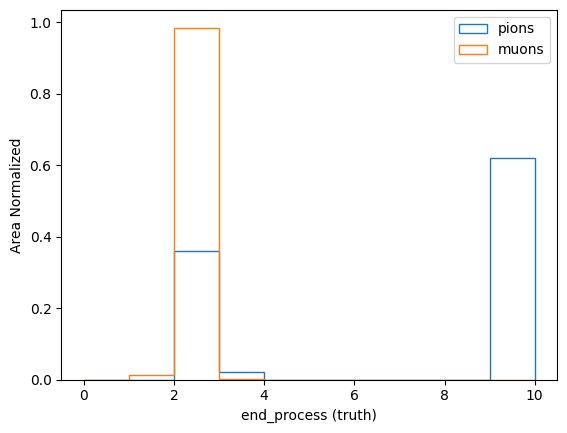

In [94]:
bins=10
myRange=(0,10)
pion_ndaughters = np.concatenate((np.array(evtdf[trunk_pion_mask].trunk.trk.truth.p.end_process), 
                                  np.array(evtdf[branch_pion_mask].branch.trk.truth.p.end_process)))

muon_ndaughters = np.concatenate((np.array(evtdf[trunk_muon_mask].trunk.trk.truth.p.end_process), 
                                  np.array(evtdf[branch_muon_mask].branch.trk.truth.p.end_process)))

plt.hist(pion_ndaughters, weights=pion_weights, bins=bins, range=myRange, label='pions', histtype='step', density=True)
plt.hist(muon_ndaughters, weights=muon_weights, bins=bins, range=myRange, label='muons', histtype='step', density=True)
plt.legend()
plt.ylabel('Area Normalized')
plt.xlabel('end_process (truth)')
plt.show()

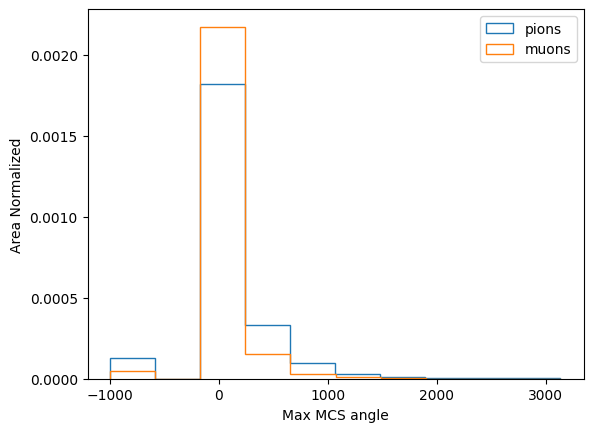

-999.0
3141.4763


In [98]:
bins=10
myRange=(0,10)
pion_mcs_angle = np.concatenate((np.array(evtdf[trunk_pion_mask].trunk.trk.mcsP.max_angle), 
                                  np.array(evtdf[branch_pion_mask].branch.trk.mcsP.max_angle)))

muon_mcs_angle = np.concatenate((np.array(evtdf[trunk_muon_mask].trunk.trk.mcsP.max_angle), 
                                  np.array(evtdf[branch_muon_mask].branch.trk.mcsP.max_angle)))

plt.hist(pion_mcs_angle, weights=pion_weights, label='pions', histtype='step', density=True)
plt.hist(muon_mcs_angle, weights=muon_weights, label='muons', histtype='step', density=True)
plt.legend()
plt.ylabel('Area Normalized')
plt.xlabel('Max MCS angle')
plt.show()

print(min(muon_mcs_angle))
print(max(muon_mcs_angle))

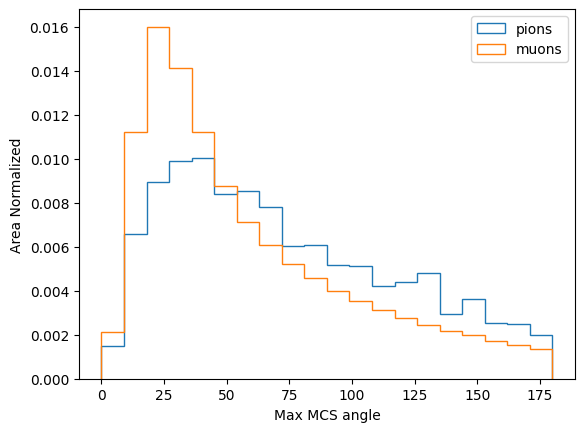

-999.0
3141.4763


In [100]:
bins=20
myRange=(0,180.)
pion_mcs_angle = np.concatenate((np.array(evtdf[trunk_pion_mask].trunk.trk.mcsP.max_angle), 
                                  np.array(evtdf[branch_pion_mask].branch.trk.mcsP.max_angle)))

muon_mcs_angle = np.concatenate((np.array(evtdf[trunk_muon_mask].trunk.trk.mcsP.max_angle), 
                                  np.array(evtdf[branch_muon_mask].branch.trk.mcsP.max_angle)))

plt.hist(pion_mcs_angle, bins=bins, range=myRange, weights=pion_weights, label='pions', histtype='step', density=True)
plt.hist(muon_mcs_angle, bins=bins, range=myRange, weights=muon_weights, label='muons', histtype='step', density=True)
plt.legend()
plt.ylabel('Area Normalized')
plt.xlabel('Max MCS angle')
plt.show()

print(min(muon_mcs_angle))
print(max(muon_mcs_angle))

In [99]:
muon_mcs_angle

array([ 52.47788 ,  61.73735 ,  14.871277, ..., 119.8468  ,  53.962803,
        75.309105], dtype=float32)

In [ ]:
pion_mcs_angle = np.concatenate((np.array(evtdf[trunk_pion_mask].trunk.trk.mcsP.mean_angle), 
                                  np.array(evtdf[branch_pion_mask].branch.trk.mcsP.mean_angle)))

muon_mcs_angle = np.concatenate((np.array(evtdf[trunk_muon_mask].trunk.trk.mcsP.mean_angle), 
                                  np.array(evtdf[branch_muon_mask].branch.trk.mcsP.mean_angle)))

mybins=20
myrange=(0,1000)
plt.hist(pion_mcs_angle, weights=pion_weights, label='pions', histtype='step', density=True, bins=mybins, range=myrange)
plt.hist(muon_mcs_angle, weights=muon_weights, label='muons', histtype='step', density=True, bins=mybins, range=myrange)
plt.legend()
plt.ylabel('Area Normalized')
plt.xlabel('Mean MCS angle')
plt.show()

print(min(muon_mcs_angle))
print(max(muon_mcs_angle))

In [83]:
for c in evtdf.columns:
    print(c)

('slc', 'is_clear_cosmic', '', '', '', '')
('slc', 'vertex', 'x', '', '', '')
('slc', 'vertex', 'y', '', '', '')
('slc', 'vertex', 'z', '', '', '')
('slc', 'self', '', '', '', '')
('slc', 'tmatch', 'eff', '', '', '')
('slc', 'tmatch', 'pur', '', '', '')
('slc', 'tmatch', 'idx', '', '', '')
('slc', 'producer', '', '', '', '')
('slc', 'nuid', 'crlongtrkdiry', '', '', '')
('slc', 'reco', 'nstub', '', '', '')
('slc', 'reco', 'npfp', '', '', '')
('slc', 'fmatch', 'time', '', '', '')
('slc', 'truth', 'E', '', '', '')
('slc', 'truth', 'time', '', '', '')
('slc', 'truth', 'bjorkenX', '', '', '')
('slc', 'truth', 'inelasticityY', '', '', '')
('slc', 'truth', 'Q2', '', '', '')
('slc', 'truth', 'w', '', '', '')
('slc', 'truth', 'momentum', 'x', '', '')
('slc', 'truth', 'momentum', 'y', '', '')
('slc', 'truth', 'momentum', 'z', '', '')
('slc', 'truth', 'position', 'x', '', '')
('slc', 'truth', 'position', 'y', '', '')
('slc', 'truth', 'position', 'z', '', '')
('slc', 'truth', 'pdg', '', '', '')
('